In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, StratifiedKFold

from opfython.models import SupervisedOPF
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, balanced_accuracy_score, matthews_corrcoef, average_precision_score

from sklearn.neighbors import KNeighborsClassifier, NearestCentroid
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC as SupportVectorMachineClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

from sklearn.inspection import permutation_importance

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import ParameterGrid

# Resampling removido: não faz parte do protocolo.

from scipy.stats import wilcoxon
import scipy.stats as st

import logging
opfython_logger = logging.getLogger("opfython")
opfython_logger.setLevel(logging.CRITICAL + 1)
opfython_logger.propagate = False
import warnings

In [2]:
df = pd.read_csv('NPHA-doctor-visits.csv')

In [3]:
df

,Number of Doctors Visited,Age,Phyiscal Health,Mental Health,Dental Health,Employment,Stress Keeps Patient from Sleeping,Medication Keeps Patient from Sleeping,Pain Keeps Patient from Sleeping,Bathroom Needs Keeps Patient from Sleeping,Uknown Keeps Patient from Sleeping,Trouble Sleeping,Prescription Sleep Medication,Race,Gender
0,3,2,4,3,3,3,0,0,0,0,1,2,3,1,2
1,2,2,4,2,3,3,1,0,0,1,0,3,3,1,1
2,3,2,3,2,3,3,0,0,0,0,1,3,3,4,1
3,1,2,3,2,3,3,0,0,0,1,0,3,3,4,2
4,3,2,3,3,3,3,1,0,0,0,0,2,3,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
709,2,2,2,2,2,3,0,0,0,1,0,3,3,1,1
710,3,2,2,2,2,2,1,0,0,0,1,2,3,1,2
711,3,2,4,2,3,3,0,0,0,0,0,3,3,1,1
712,3,2,3,1,3,3,1,0,1,1,1,3,3,1,2


In [4]:
df.shape

(714, 15)

In [5]:
df.isna().sum()

Number of Doctors Visited                     0
Age                                           0
Phyiscal Health                               0
Mental Health                                 0
Dental Health                                 0
Employment                                    0
Stress Keeps Patient from Sleeping            0
Medication Keeps Patient from Sleeping        0
Pain Keeps Patient from Sleeping              0
Bathroom Needs Keeps Patient from Sleeping    0
Uknown Keeps Patient from Sleeping            0
Trouble Sleeping                              0
Prescription Sleep Medication                 0
Race                                          0
Gender                                        0
dtype: int64

In [6]:
df

,Number of Doctors Visited,Age,Phyiscal Health,Mental Health,Dental Health,Employment,Stress Keeps Patient from Sleeping,Medication Keeps Patient from Sleeping,Pain Keeps Patient from Sleeping,Bathroom Needs Keeps Patient from Sleeping,Uknown Keeps Patient from Sleeping,Trouble Sleeping,Prescription Sleep Medication,Race,Gender
0,3,2,4,3,3,3,0,0,0,0,1,2,3,1,2
1,2,2,4,2,3,3,1,0,0,1,0,3,3,1,1
2,3,2,3,2,3,3,0,0,0,0,1,3,3,4,1
3,1,2,3,2,3,3,0,0,0,1,0,3,3,4,2
4,3,2,3,3,3,3,1,0,0,0,0,2,3,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
709,2,2,2,2,2,3,0,0,0,1,0,3,3,1,1
710,3,2,2,2,2,2,1,0,0,0,1,2,3,1,2
711,3,2,4,2,3,3,0,0,0,0,0,3,3,1,1
712,3,2,3,1,3,3,1,0,1,1,1,3,3,1,2


In [7]:
#histograma das features

# features = df.select_dtypes(include=['number']).columns

# for feature in features:
#     plt.figure(figsize=(8, 6))
#     sns.histplot(data=df, x=feature, hue='Number of Doctors Visited', kde=False, bins=50, palette="pastel")

#     plt.xlabel(feature)
#     plt.ylabel("Contagem")
#     plt.title(f"Distribuição da feature: {feature}")
#     plt.legend(title="Class")
#     plt.show()

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 714 entries, 0 to 713
Data columns (total 15 columns):
 #   Column                                      Non-Null Count  Dtype
---  ------                                      --------------  -----
 0   Number of Doctors Visited                   714 non-null    int64
 1   Age                                         714 non-null    int64
 2   Phyiscal Health                             714 non-null    int64
 3   Mental Health                               714 non-null    int64
 4   Dental Health                               714 non-null    int64
 5   Employment                                  714 non-null    int64
 6   Stress Keeps Patient from Sleeping          714 non-null    int64
 7   Medication Keeps Patient from Sleeping      714 non-null    int64
 8   Pain Keeps Patient from Sleeping            714 non-null    int64
 9   Bathroom Needs Keeps Patient from Sleeping  714 non-null    int64
 10  Uknown Keeps Patient from Sleeping          714 n

In [9]:
df.describe()

,Number of Doctors Visited,Age,Phyiscal Health,Mental Health,Dental Health,Employment,Stress Keeps Patient from Sleeping,Medication Keeps Patient from Sleeping,Pain Keeps Patient from Sleeping,Bathroom Needs Keeps Patient from Sleeping,Uknown Keeps Patient from Sleeping,Trouble Sleeping,Prescription Sleep Medication,Race,Gender
count,714.000000,714.0,714.000000,714.000000,714.000000,714.000000,714.000000,714.000000,714.000000,714.000000,714.000000,714.000000,714.000000,714.000000,714.00000
mean,2.112045,2.0,2.794118,1.988796,3.009804,2.806723,0.247899,0.056022,0.218487,0.504202,0.417367,2.407563,2.829132,1.425770,1.55042
std,0.683441,0.0,0.900939,0.939928,1.361117,0.586582,0.432096,0.230126,0.413510,0.500333,0.493470,0.670349,0.546767,1.003896,0.49780
min,1.000000,2.0,-1.000000,-1.000000,-1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,-1.000000,1.000000,1.00000
25%,2.000000,2.0,2.000000,1.000000,2.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,3.000000,1.000000,1.00000
50%,2.000000,2.0,3.000000,2.000000,3.000000,3.000000,0.000000,0.000000,0.000000,1.000000,0.000000,3.000000,3.000000,1.000000,2.00000
75%,3.000000,2.0,3.000000,3.000000,4.000000,3.000000,0.000000,0.000000,0.000000,1.000000,1.000000,3.000000,3.000000,1.000000,2.00000
max,3.000000,2.0,5.000000,5.000000,6.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,3.000000,5.000000,2.00000


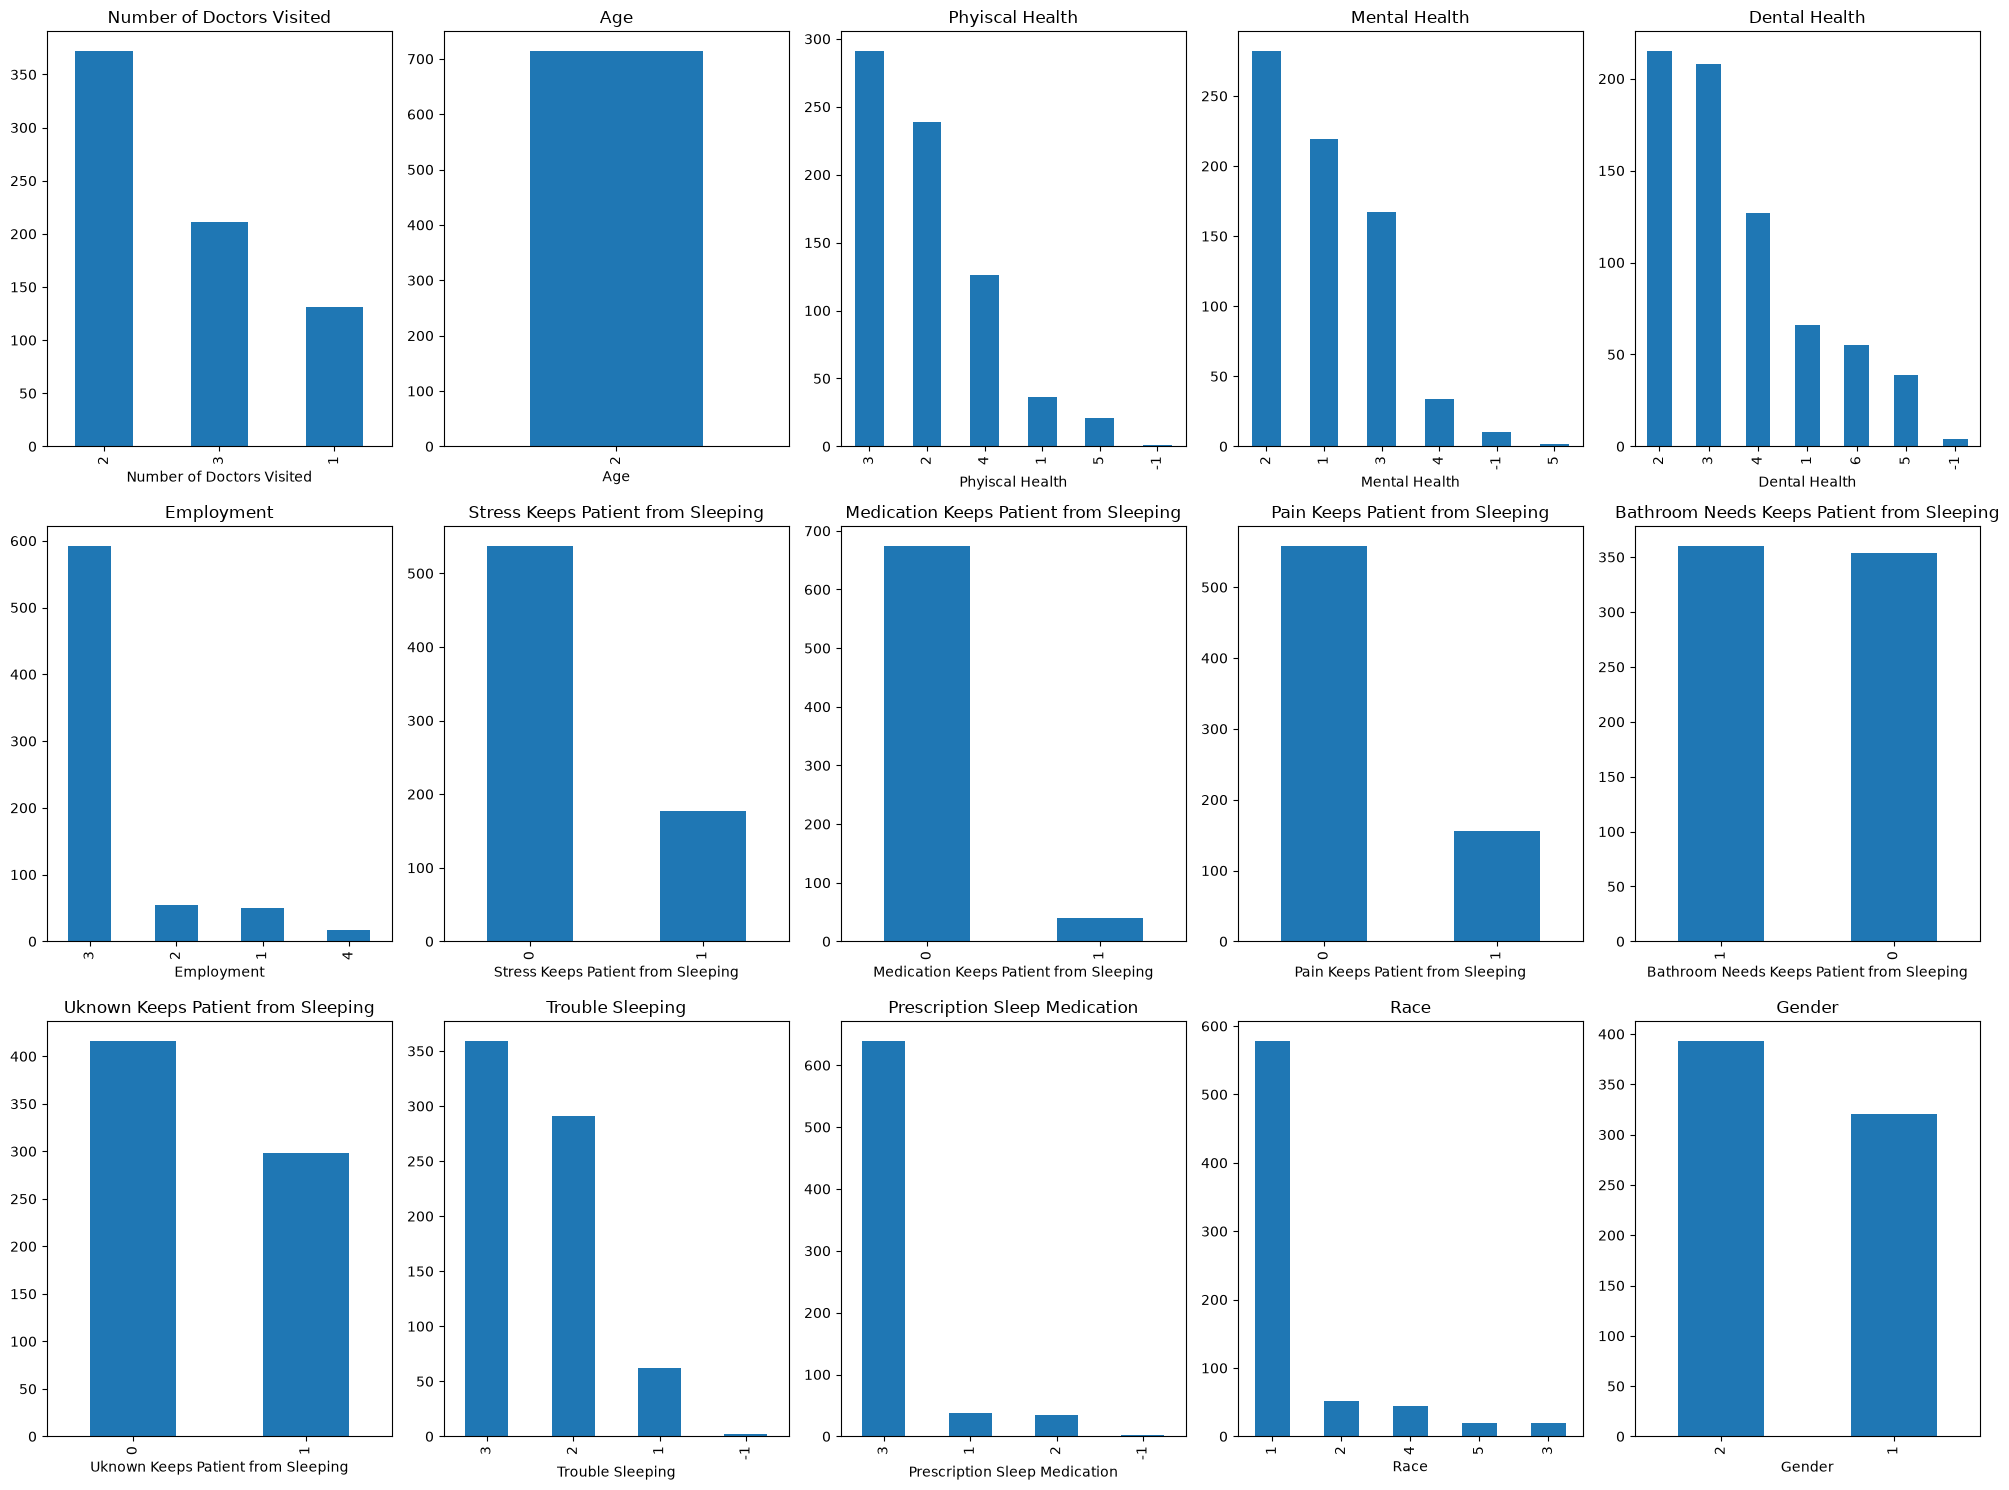

In [10]:
# visualizing the distribution of the features
fig, axes = plt.subplots(3, 5, figsize=(20, 15))
axes = axes.ravel()

for i, column in enumerate(df.columns):
    df[column].value_counts().plot(kind='bar', ax=axes[i])
    axes[i].set_title(column)

plt.tight_layout()
plt.show()

In [11]:
df['Number of Doctors Visited'].describe()

count    714.000000
mean       2.112045
std        0.683441
min        1.000000
25%        2.000000
50%        2.000000
75%        3.000000
max        3.000000
Name: Number of Doctors Visited, dtype: float64

In [12]:
df['Age'].describe()

count    714.0
mean       2.0
std        0.0
min        2.0
25%        2.0
50%        2.0
75%        2.0
max        2.0
Name: Age, dtype: float64

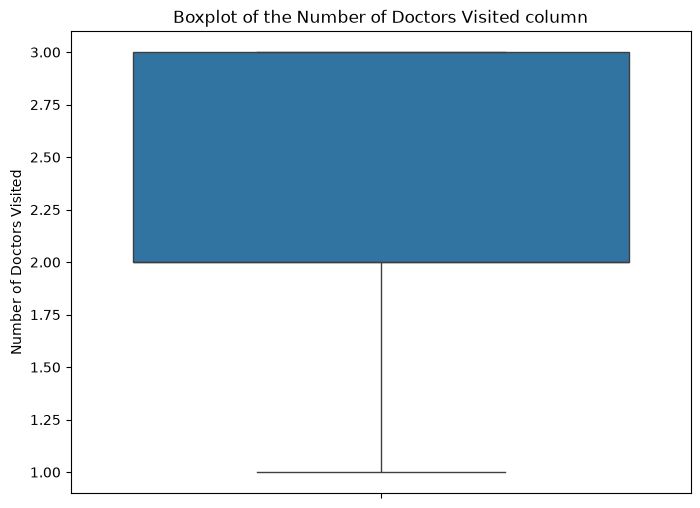

In [13]:
plt.figure(figsize=(8, 6))
sns.boxplot(y='Number of Doctors Visited', data=df)
plt.title("Boxplot of the Number of Doctors Visited column")
plt.show()

In [14]:
Q1_UP = df['Number of Doctors Visited'].quantile(0.25)
Q2_UP = df['Number of Doctors Visited'].quantile(0.5)
Q3_UP = df['Number of Doctors Visited'].quantile(0.75)

lower_limit_UP = Q1_UP - 1.5 * (Q3_UP - Q1_UP)
upper_limit_UP = Q3_UP + 1.5 * (Q3_UP - Q1_UP)

print(f"Feature: Number of Doctors Visited")
print(f"- Q1: {Q1_UP:.2f}")
print(f"- Q2 (Mediana): {Q2_UP:.2f}")
print(f"- Q3: {Q3_UP:.2f}")
print(f"- Limite Inferior: {lower_limit_UP:.2f}")
print(f"- Limite Superior: {upper_limit_UP:.2f}")

Feature: Number of Doctors Visited
- Q1: 2.00
- Q2 (Mediana): 2.00
- Q3: 3.00
- Limite Inferior: 0.50
- Limite Superior: 4.50


Existe um viés na Classe 2. Portanto seria bom utilizar tecnica de  subamostragem para a classe super-representada.

In [15]:
# Calculate the class distribution
class_distribution = df['Number of Doctors Visited'].value_counts()
print(class_distribution)

Number of Doctors Visited
2    372
3    211
1    131
Name: count, dtype: int64


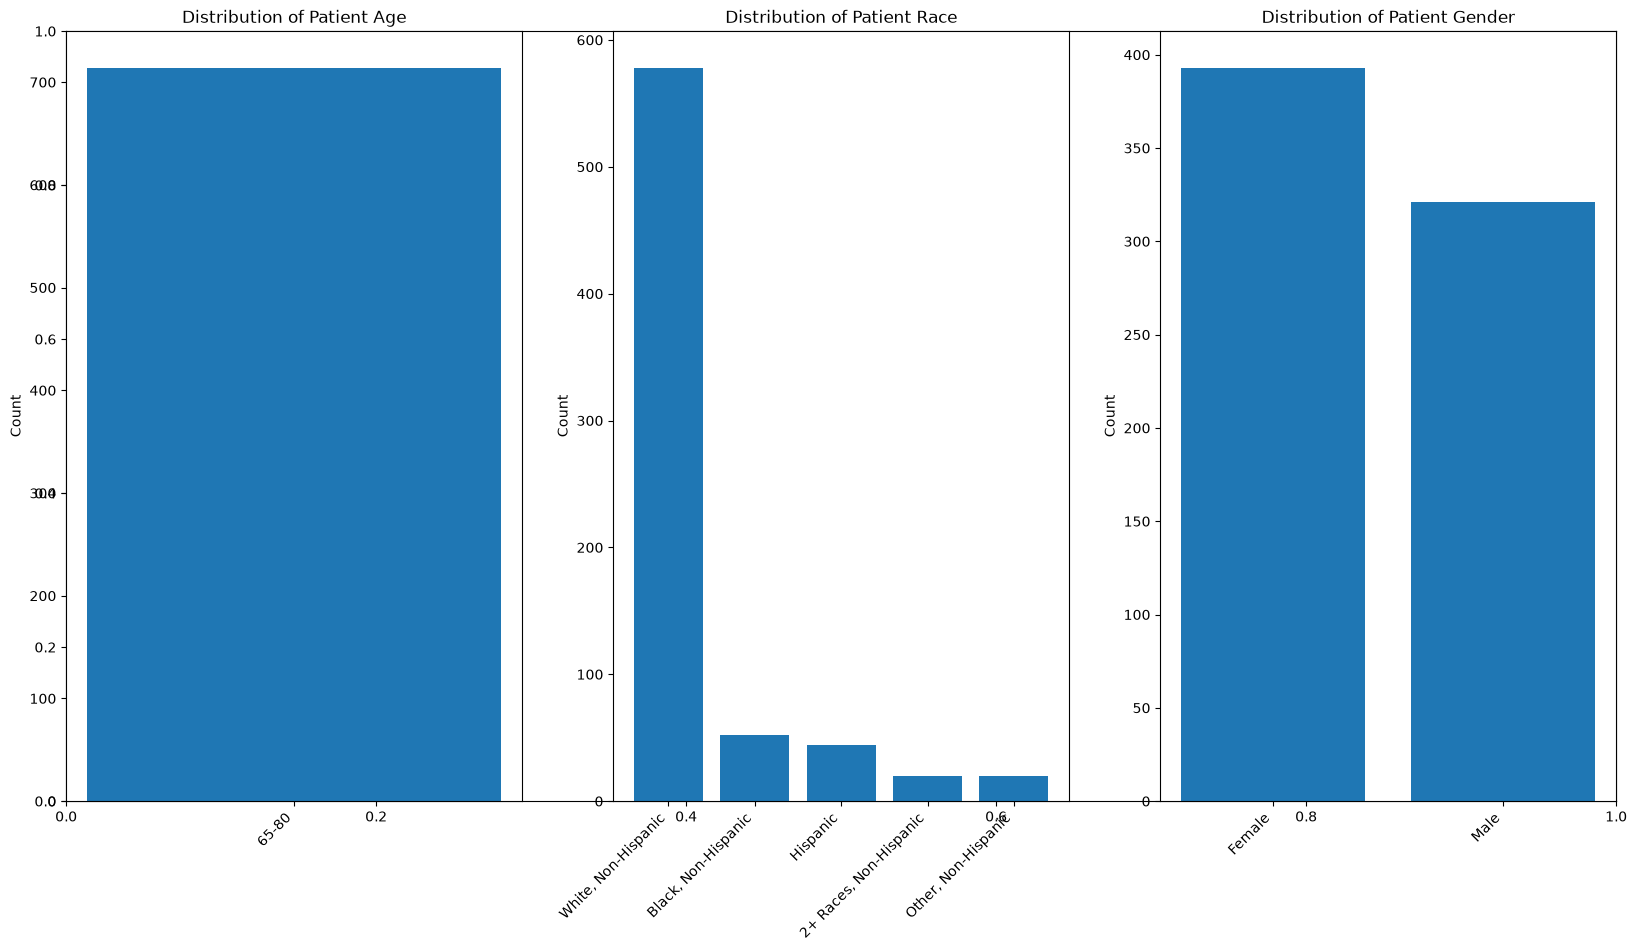

In [16]:
df_ = df.copy()

age_dict = { 1: "50-64", 2: "65-80" }
df_['Age'] = df_['Age'].map(age_dict)

race_dict = { 1: "White, Non-Hispanic", 2: "Black, Non-Hispanic", 3: "Other, Non-Hispanic", 4: "Hispanic", 5: "2+ Races, Non-Hispanic" }
df_['Race'] = df_['Race'].map(race_dict)

gender_dict = { 1: "Male", 2: "Female" }
df_['Gender'] = df_['Gender'].map(gender_dict)

plt.subplots(figsize=(20, 10))
for i, col in enumerate(['Age', 'Race' , 'Gender']):
    plt.subplot(1, 3, i + 1)

    x = df_[col].value_counts()
    plt.bar(x.index, x.values)
    plt.title('Distribution of Patient ' + col)
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Count')

plt.show()

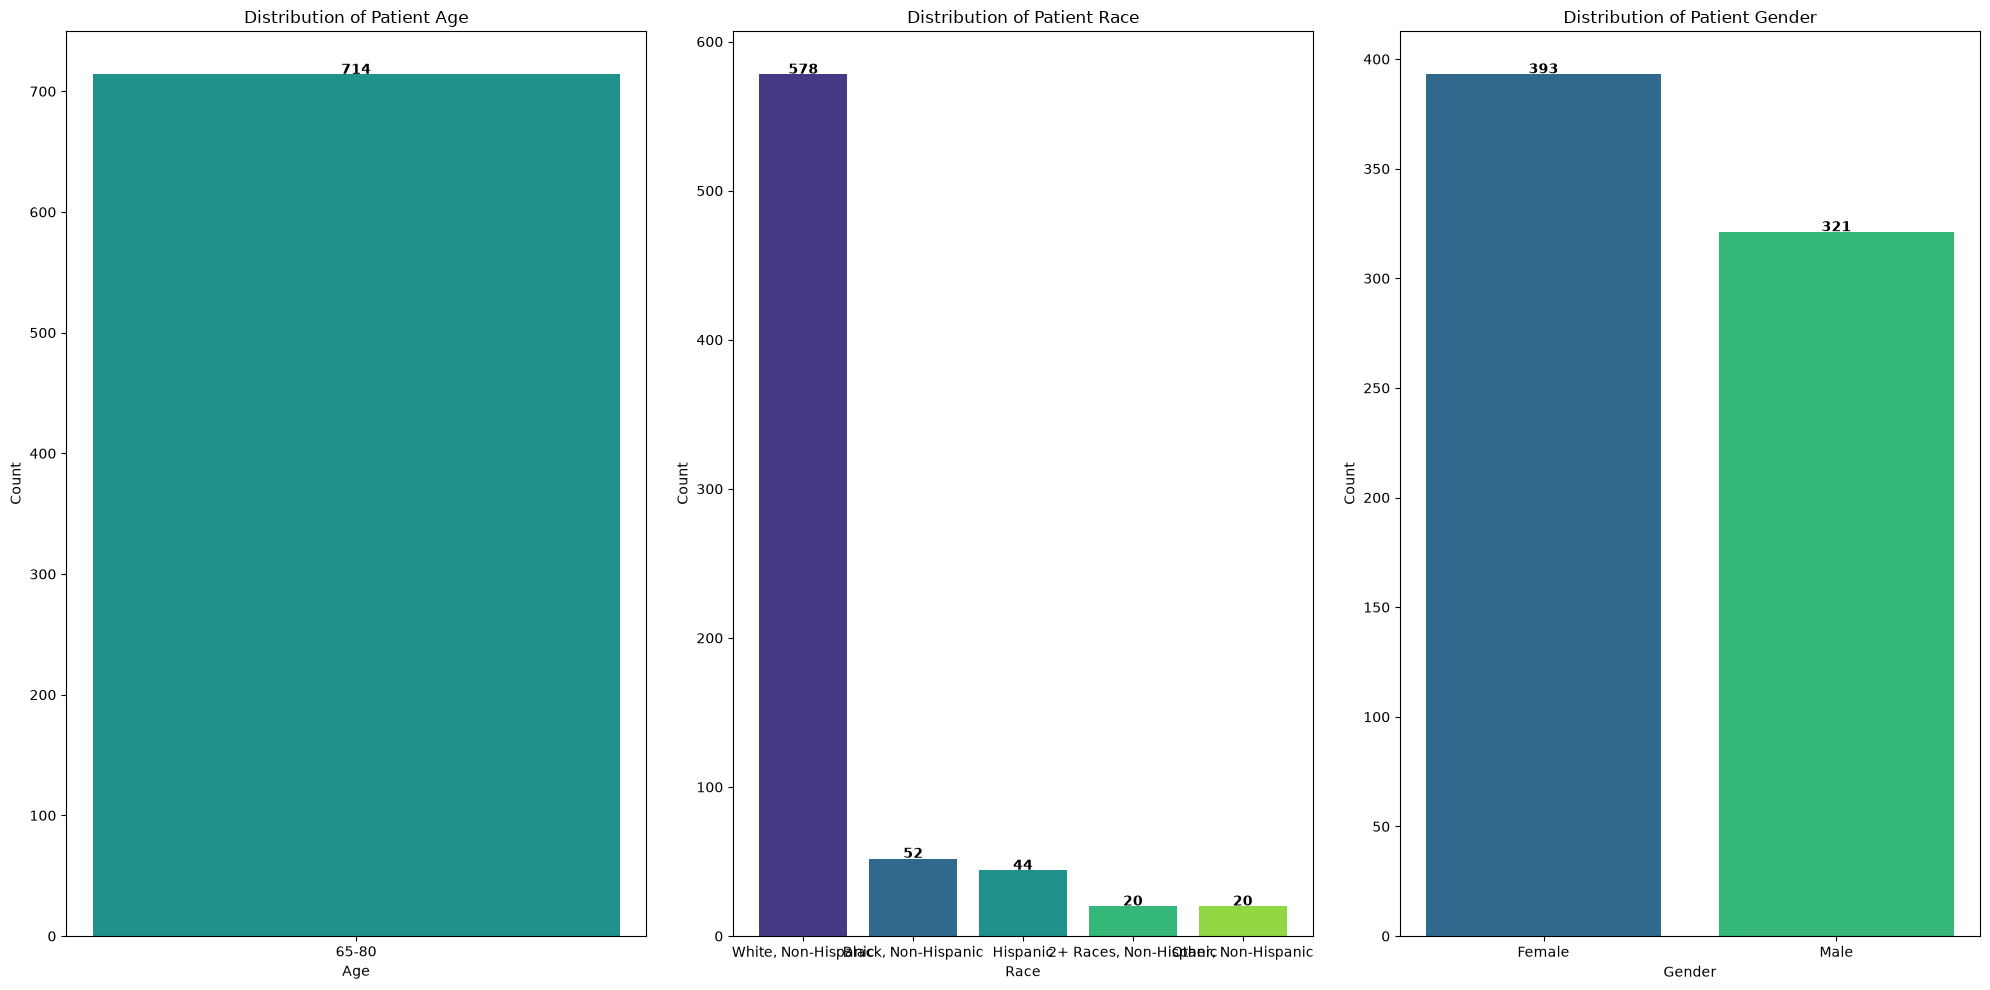

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(20, 10))
for i, col in enumerate(['Age', 'Race', 'Gender']):
    x = df_[col].value_counts()
    axes[i].bar(x.index.astype(str), x.values, color=sns.color_palette("viridis", len(x)))
    axes[i].set_title('Distribution of Patient ' + col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    # Adicionar valores em cima das barras
    for j, v in enumerate(x.values):
        axes[i].text(j, v + 0.5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


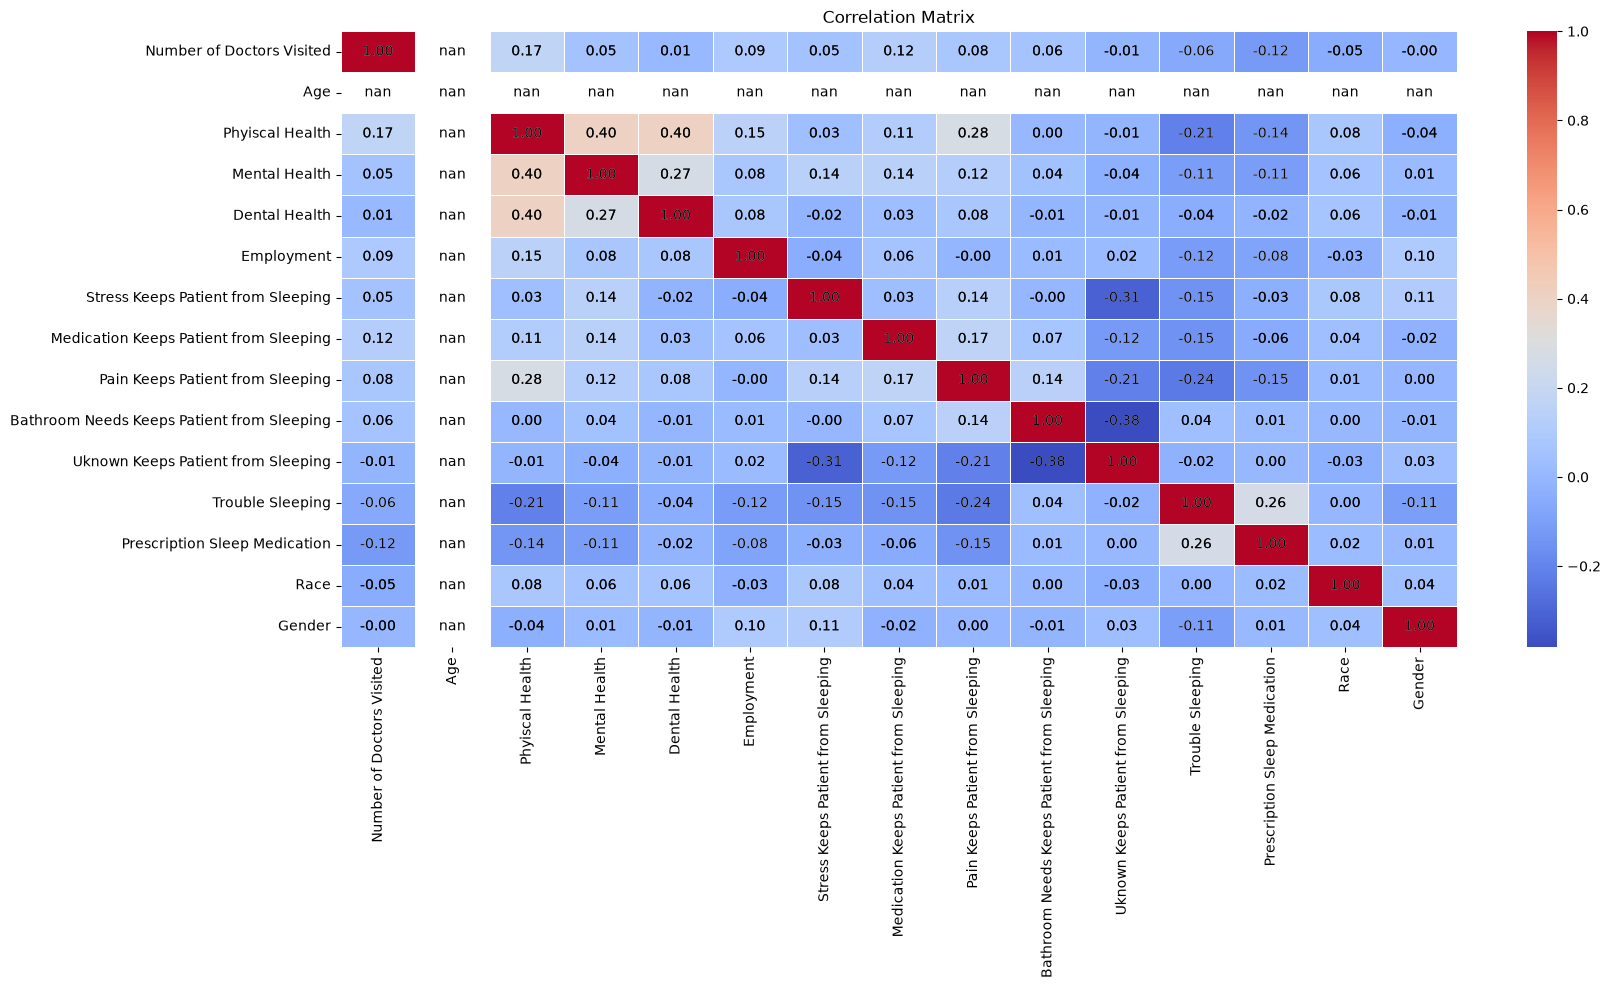

In [18]:
# Calculate the correlation matrix
corr_matrix = df.corr()

# Create a heatmap
plt.figure(figsize=(18, 8))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=True, fmt=".2f", linewidths=0.5)

# Add annotations to the heatmap
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        text = f"{corr_matrix.iloc[i, j]:.2f}"
        plt.text(j + 0.5, i + 0.5, text, ha='center', va='center', color='black')

plt.title("Correlation Matrix")
plt.show()

In [19]:
# Target documentado: 1 consulta -> 0; 2/3 consultas -> 1.
df['Number of Doctors Visited'] = df['Number of Doctors Visited'].map({1: 0, 2: 1, 3: 1}).astype('int8')
class_counts = df['Number of Doctors Visited'].value_counts().sort_index()
class_percentages = df['Number of Doctors Visited'].value_counts(normalize=True).sort_index().mul(100)
print('Target: 0=0-1 consulta; 1=2+ consultas')
print(pd.DataFrame({'count': class_counts, 'percent': class_percentages}))

Target: 0=0-1 consulta; 1=2+ consultas
                           count    percent
Number of Doctors Visited                  
0                            131  18.347339
1                            583  81.652661


LEGADO: codificação do alvo desativada; pipeline final usa target binário explícito.

In [20]:
categorical_features = [c for c in df.columns if c != 'Number of Doctors Visited']
df_encoded = pd.get_dummies(df, columns=categorical_features, drop_first=False)
df_encoded

,Number of Doctors Visited,Age_2,Phyiscal Health_-1,Phyiscal Health_1,Phyiscal Health_2,Phyiscal Health_3,Phyiscal Health_4,Phyiscal Health_5,Mental Health_-1,Mental Health_1,...,Prescription Sleep Medication_1,Prescription Sleep Medication_2,Prescription Sleep Medication_3,Race_1,Race_2,Race_3,Race_4,Race_5,Gender_1,Gender_2
0,1,True,False,False,False,False,True,False,False,False,...,False,False,True,True,False,False,False,False,False,True
1,1,True,False,False,False,False,True,False,False,False,...,False,False,True,True,False,False,False,False,True,False
2,1,True,False,False,False,True,False,False,False,False,...,False,False,True,False,False,False,True,False,True,False
3,0,True,False,False,False,True,False,False,False,False,...,False,False,True,False,False,False,True,False,False,True
4,1,True,False,False,False,True,False,False,False,False,...,False,False,True,True,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
709,1,True,False,False,True,False,False,False,False,False,...,False,False,True,True,False,False,False,False,True,False
710,1,True,False,False,True,False,False,False,False,False,...,False,False,True,True,False,False,False,False,False,True
711,1,True,False,False,False,False,True,False,False,False,...,False,False,True,True,False,False,False,False,True,False
712,1,True,False,False,False,True,False,False,False,True,...,False,False,True,True,False,False,False,False,False,True


In [21]:
df_encoded = df_encoded.reset_index(drop=True)

In [22]:
X = df_encoded.drop(columns=['Number of Doctors Visited'])
y = df_encoded['Number of Doctors Visited'].astype('int8')

In [23]:
X

,Age_2,Phyiscal Health_-1,Phyiscal Health_1,Phyiscal Health_2,Phyiscal Health_3,Phyiscal Health_4,Phyiscal Health_5,Mental Health_-1,Mental Health_1,Mental Health_2,...,Prescription Sleep Medication_1,Prescription Sleep Medication_2,Prescription Sleep Medication_3,Race_1,Race_2,Race_3,Race_4,Race_5,Gender_1,Gender_2
0,True,False,False,False,False,True,False,False,False,False,...,False,False,True,True,False,False,False,False,False,True
1,True,False,False,False,False,True,False,False,False,True,...,False,False,True,True,False,False,False,False,True,False
2,True,False,False,False,True,False,False,False,False,True,...,False,False,True,False,False,False,True,False,True,False
3,True,False,False,False,True,False,False,False,False,True,...,False,False,True,False,False,False,True,False,False,True
4,True,False,False,False,True,False,False,False,False,False,...,False,False,True,True,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
709,True,False,False,True,False,False,False,False,False,True,...,False,False,True,True,False,False,False,False,True,False
710,True,False,False,True,False,False,False,False,False,True,...,False,False,True,True,False,False,False,False,False,True
711,True,False,False,False,False,True,False,False,False,True,...,False,False,True,True,False,False,False,False,True,False
712,True,False,False,False,True,False,False,False,True,False,...,False,False,True,True,False,False,False,False,False,True


In [24]:
y

0      1
1      1
2      1
3      0
4      1
      ..
709    1
710    1
711    1
712    1
713    1
Name: Number of Doctors Visited, Length: 714, dtype: int8

In [25]:
# feature_importances = pd.DataFrame(model.feature_importances_,
#                                    index = X.columns,
#                                    columns=['importance']).sort_values('importance', ascending=False)

# # Plotting
# plt.figure(figsize=(10, 6))
# feature_importances.plot(kind='barh')

In [26]:
y

0      1
1      1
2      1
3      0
4      1
      ..
709    1
710    1
711    1
712    1
713    1
Name: Number of Doctors Visited, Length: 714, dtype: int8

In [27]:
colunas_lixo = [
    'Race_5', 'Uknown Keeps Patient from Sleeping_0', 'Prescription Sleep Medication_2',
    'Phyiscal Health_1', 'Mental Health_-1', 'Race_4', 'Dental Health_1',
    'Prescription Sleep Medication_-1', 'Dental Health_-1', 'Mental Health_5',
    'Phyiscal Health_-1', 'Age_2', 'Gender_1', 'Phyiscal Health_3', 'Phyiscal Health_5', 'Dental Health_3',
    'Race_2', 'Trouble Sleeping_3', 'Mental Health_3', 'Gender_2',
    'Employment_1', 'Trouble Sleeping_2', 'Dental Health_6', 'Trouble Sleeping_-1'
]

In [28]:
X = X.drop(columns=colunas_lixo)

In [29]:
print(f"Dimensões atuais: {X.shape}")

Dimensões atuais: (714, 25)


In [30]:
X_resampled = X.values
y_resampled = y.to_numpy()

In [31]:
y = pd.Series(y_resampled, name='Number of Doctors Visited').astype('int8')
class_distribution = y.value_counts().sort_index()
print("Class distribution (sem resampling):")
print(class_distribution)

Class distribution (sem resampling):
Number of Doctors Visited
0    131
1    583
Name: count, dtype: int64


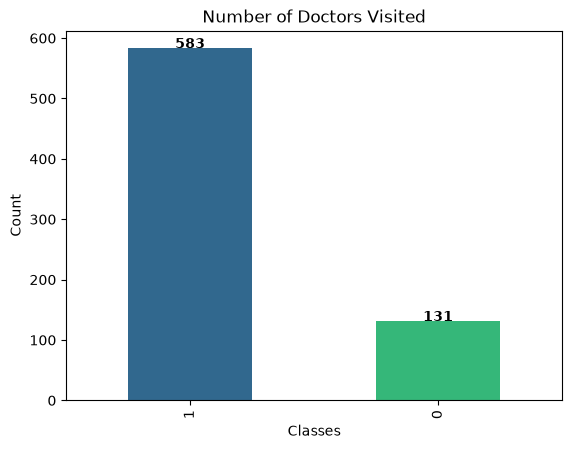

In [32]:
ax = y.value_counts().plot(kind='bar', title='Number of Doctors Visited', color=sns.color_palette("viridis", len(y.value_counts())))
ax.set_xlabel('Classes')
ax.set_ylabel('Count')
for p in ax.patches:
    ax.text(p.get_x() + p.get_width()/2, p.get_height() + 0.5, str(int(p.get_height())), ha='center', fontweight='bold')
plt.show()


In [33]:
scaler = StandardScaler()
X_escalonado = scaler.fit_transform(X)

In [34]:
pca = PCA(n_components=2)
componentes_principais = pca.fit_transform(X_escalonado)
df_pca = pd.DataFrame(data=componentes_principais, columns=['PC1', 'PC2'])
df_pca['Classe_Alvo'] = y

<Axes: xlabel='PC1', ylabel='PC2'>

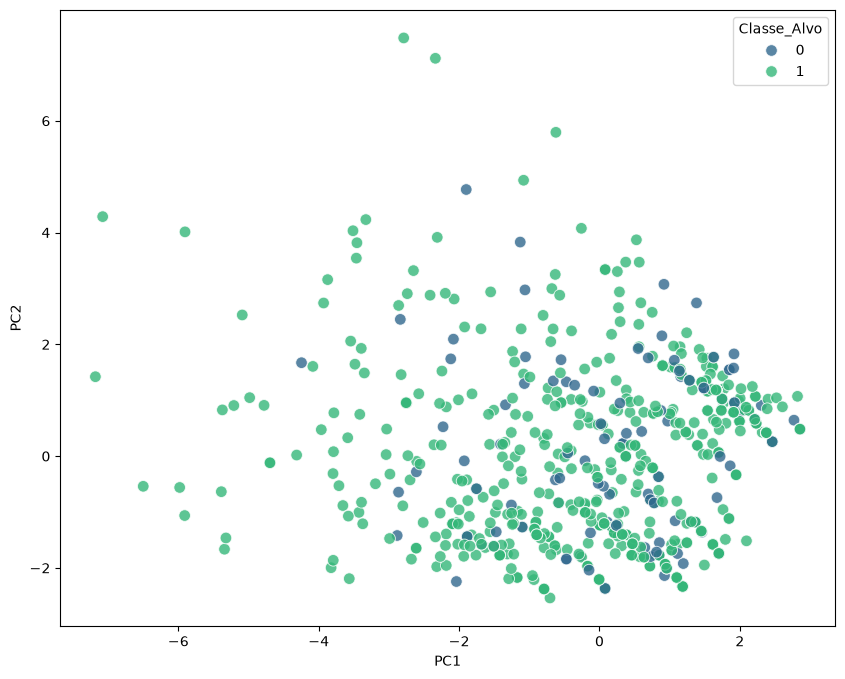

In [35]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PC1', 
    y='PC2', 
    hue='Classe_Alvo', 
    palette='viridis',
    data=df_pca, 
    alpha=0.8,
    s=70
)

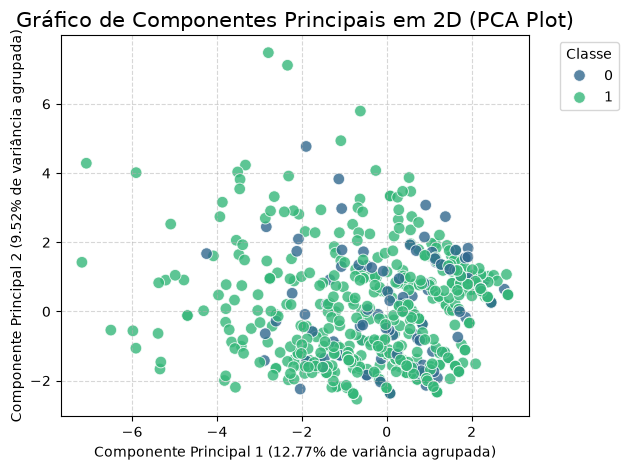

In [36]:
sns.scatterplot(x='PC1', y='PC2', hue='Classe_Alvo', palette='viridis', data=df_pca, alpha=0.8, s=70)
expl_1 = pca.explained_variance_ratio_[0]*100
expl_2 = pca.explained_variance_ratio_[1]*100
plt.title('Gráfico de Componentes Principais em 2D (PCA Plot)', fontsize=15)
plt.xlabel(f"Componente Principal 1 ({expl_1:.2f}% de variância agrupada)")
plt.ylabel(f"Componente Principal 2 ({expl_2:.2f}% de variância agrupada)")
plt.legend(title='Classe', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

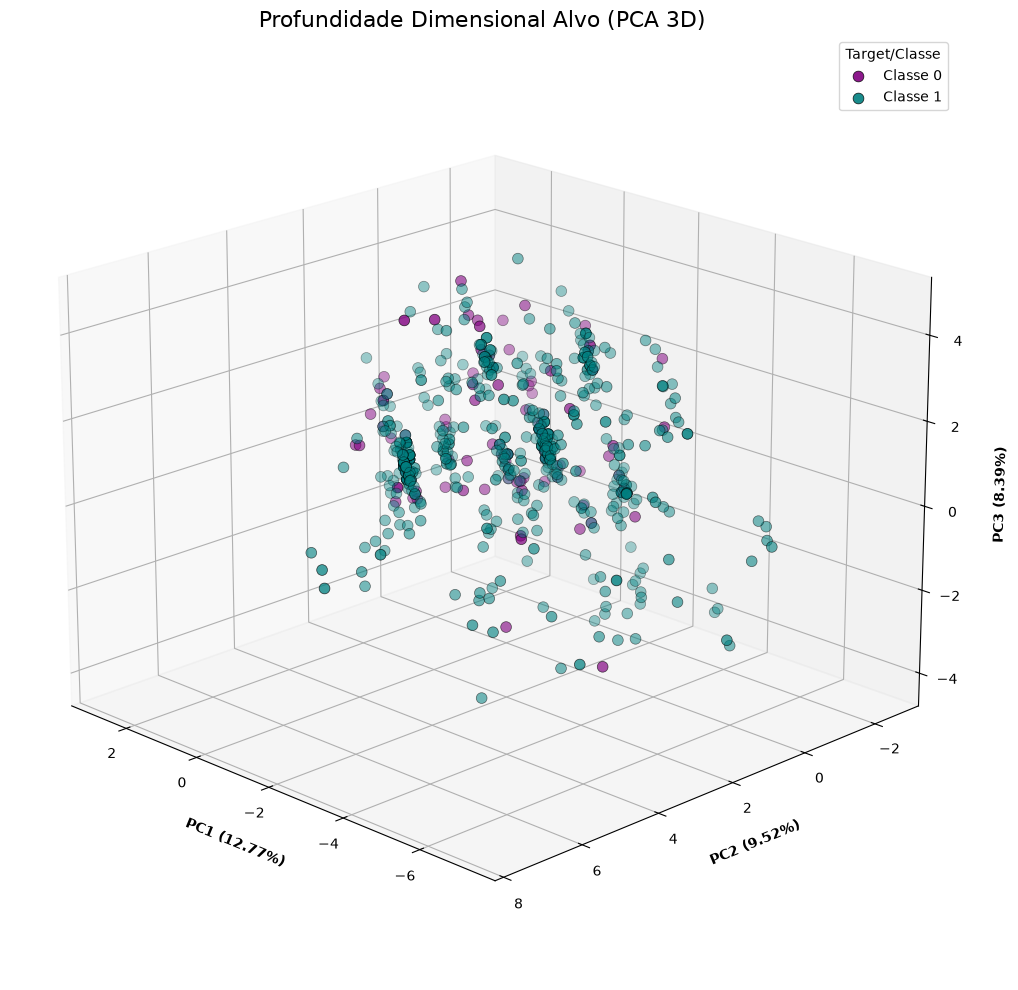

In [37]:
pca_3d = PCA(n_components=3)
comps_3d = pca_3d.fit_transform(X_escalonado)
    
df_pca3 = pd.DataFrame(data=comps_3d, columns=['PC1', 'PC2', 'PC3'])
df_pca3['Classe_Alvo'] = y
    
# Matplotlib puro pro 3D 
fig3d = plt.figure(figsize=(12, 10))
ax = fig3d.add_subplot(111, projection='3d')

cores = ['purple', 'teal', 'gold'] 
classes_unicas = sorted(list(df_pca3['Classe_Alvo'].unique()))
    
# Plota classe por classe
for cls, cor in zip(classes_unicas, cores):
    subset = df_pca3[df_pca3['Classe_Alvo'] == cls]
    ax.scatter(subset['PC1'], subset['PC2'], subset['PC3'], 
                color=cor, label=f'Classe {cls}', s=60, alpha=0.9, edgecolor='black', linewidth=0.5)

e1_3d = pca_3d.explained_variance_ratio_[0]*100
e2_3d = pca_3d.explained_variance_ratio_[1]*100
e3_3d = pca_3d.explained_variance_ratio_[2]*100

ax.set_xlabel(f"PC1 ({e1_3d:.2f}%)", fontweight='bold', labelpad=10)
ax.set_ylabel(f"PC2 ({e2_3d:.2f}%)", fontweight='bold', labelpad=10)
ax.set_zlabel(f"PC3 ({e3_3d:.2f}%)", fontweight='bold', labelpad=10)
plt.title('Profundidade Dimensional Alvo (PCA 3D)', fontsize=16)
plt.legend(title='Target/Classe', loc='best')

# Opcional (rotacionar ângulo)
ax.view_init(elev=20, azim=135)
plt.tight_layout()
plt.show()


In [38]:
df = pd.DataFrame(X, columns=X.columns)

In [39]:
df_encoded.shape

(714, 50)

In [40]:
df

,Phyiscal Health_2,Phyiscal Health_4,Mental Health_1,Mental Health_2,Mental Health_4,Dental Health_2,Dental Health_4,Dental Health_5,Employment_2,Employment_3,...,Pain Keeps Patient from Sleeping_0,Pain Keeps Patient from Sleeping_1,Bathroom Needs Keeps Patient from Sleeping_0,Bathroom Needs Keeps Patient from Sleeping_1,Uknown Keeps Patient from Sleeping_1,Trouble Sleeping_1,Prescription Sleep Medication_1,Prescription Sleep Medication_3,Race_1,Race_3
0,False,True,False,False,False,False,False,False,False,True,...,True,False,True,False,True,False,False,True,True,False
1,False,True,False,True,False,False,False,False,False,True,...,True,False,False,True,False,False,False,True,True,False
2,False,False,False,True,False,False,False,False,False,True,...,True,False,True,False,True,False,False,True,False,False
3,False,False,False,True,False,False,False,False,False,True,...,True,False,False,True,False,False,False,True,False,False
4,False,False,False,False,False,False,False,False,False,True,...,True,False,True,False,False,False,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
709,True,False,False,True,False,True,False,False,False,True,...,True,False,False,True,False,False,False,True,True,False
710,True,False,False,True,False,True,False,False,True,False,...,True,False,True,False,True,False,False,True,True,False
711,False,True,False,True,False,False,False,False,False,True,...,True,False,True,False,False,False,False,True,True,False
712,False,False,True,False,False,False,False,False,False,True,...,False,True,False,True,True,False,False,True,True,False


In [41]:
x = df

In [42]:
x

,Phyiscal Health_2,Phyiscal Health_4,Mental Health_1,Mental Health_2,Mental Health_4,Dental Health_2,Dental Health_4,Dental Health_5,Employment_2,Employment_3,...,Pain Keeps Patient from Sleeping_0,Pain Keeps Patient from Sleeping_1,Bathroom Needs Keeps Patient from Sleeping_0,Bathroom Needs Keeps Patient from Sleeping_1,Uknown Keeps Patient from Sleeping_1,Trouble Sleeping_1,Prescription Sleep Medication_1,Prescription Sleep Medication_3,Race_1,Race_3
0,False,True,False,False,False,False,False,False,False,True,...,True,False,True,False,True,False,False,True,True,False
1,False,True,False,True,False,False,False,False,False,True,...,True,False,False,True,False,False,False,True,True,False
2,False,False,False,True,False,False,False,False,False,True,...,True,False,True,False,True,False,False,True,False,False
3,False,False,False,True,False,False,False,False,False,True,...,True,False,False,True,False,False,False,True,False,False
4,False,False,False,False,False,False,False,False,False,True,...,True,False,True,False,False,False,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
709,True,False,False,True,False,True,False,False,False,True,...,True,False,False,True,False,False,False,True,True,False
710,True,False,False,True,False,True,False,False,True,False,...,True,False,True,False,True,False,False,True,True,False
711,False,True,False,True,False,False,False,False,False,True,...,True,False,True,False,False,False,False,True,True,False
712,False,False,True,False,False,False,False,False,False,True,...,False,True,False,True,True,False,False,True,True,False


In [43]:
x = x.values

In [44]:
x

array([[False,  True, False, ...,  True,  True, False],
       [False,  True, False, ...,  True,  True, False],
       [False, False, False, ...,  True, False, False],
       ...,
       [False,  True, False, ...,  True,  True, False],
       [False, False,  True, ...,  True,  True, False],
       [False, False, False, ...,  True,  True, False]], shape=(714, 25))

# Protocolo experimental canônico
As células 0–45 são EDA histórica e não fornecem objetos ao treino. Este bloco recarrega os dados, fixa o protocolo e separa resultados corrigidos de resultados legados.


In [45]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import platform
import sys
import warnings
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
import sklearn
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
    precision_recall_curve,
    roc_curve,
    roc_auc_score,
)
from sklearn.model_selection import ParameterGrid, StratifiedKFold
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier, NearestCentroid
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from opfython.models import SupervisedOPF
from xgboost import XGBClassifier

SEED = 42
TARGET_COLUMN = "Number of Doctors Visited"
TARGET_MAP = {1: 0, 2: 1, 3: 1}
TARGET_LABELS = {0: "0–1 consulta", 1: "2+ consultas"}
DATA_PATH = Path("src/NPHA-doctor-visits.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("NPHA-doctor-visits.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("/home/pk/Studing/projects/machine_learning/Artigo_veis/analyze-medical-services/src/NPHA-doctor-visits.csv")
assert DATA_PATH.exists(), "CSV não encontrado"
raw_data = pd.read_csv(DATA_PATH)
assert len(raw_data) == 714, f"n inesperado: {len(raw_data)}"
assert TARGET_COLUMN in raw_data.columns
assert set(raw_data[TARGET_COLUMN].dropna().unique()).issubset(TARGET_MAP)
y = raw_data[TARGET_COLUMN].map(TARGET_MAP).astype("int8")
assert set(y.unique()) == {0, 1}
X = raw_data.drop(columns=[TARGET_COLUMN]).copy()
class_counts = y.value_counts().sort_index()
class_percentages = y.value_counts(normalize=True).sort_index().mul(100)
print("Target:", TARGET_LABELS)
print(class_counts)
print(class_percentages)

outer_cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
y_array = y.to_numpy()
fold_indices = []
for outer_fold, (train_index, test_index) in enumerate(outer_cv.split(X, y_array), 1):
    fold_indices.append({
        "outer_fold": outer_fold,
        "train_index": train_index.tolist(),
        "test_index": test_index.tolist(),
    })

param_grid_KNN = {
    "n_neighbors": [5, 10, 20],
    "weights": ["uniform", "distance"],
}
param_grid_DT = {
    "max_depth": [3, 5, 7, None],
    "min_samples_leaf": [1, 5],
}
param_grid_RF = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, None],
    "min_samples_leaf": [1, 5],
}
param_grid_SVM = {
    "C": [0.1, 1, 10],
    "kernel": ["linear", "rbf"],
}
param_grid_MLP = {
    "hidden_layer_sizes": [(32,), (32, 16)],
    "alpha": [0.0001, 0.01],
    "max_iter": [500],
}
param_grid_LR = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["lbfgs"],
    "max_iter": [1000],
}
param_grid_XGB = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.1],
}
param_grid_NB = {"var_smoothing": [1e-11, 1e-9, 1e-7]}
param_grid_NC = {
    "metric": ["euclidean", "manhattan"],
    "shrink_threshold": [None, 0.1],
}
param_grid_OPF = {"distance": ["euclidean", "manhattan"]}
param_grid_AdaBoost = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.05, 0.1, 1.0],
}
param_grid_Dummy = {"strategy": ["most_frequent"]}


Target: {0: '0–1 consulta', 1: '2+ consultas'}
Number of Doctors Visited
0    131
1    583
Name: count, dtype: int64
Number of Doctors Visited
0    18.347339
1    81.652661
Name: proportion, dtype: float64


In [46]:
def build_preprocessor(frame):
    numeric = frame.select_dtypes(include=[np.number]).columns.tolist()
    categorical = [column for column in frame.columns if column not in numeric]
    transformers = []
    if numeric:
        transformers.append(
            (
                "numeric",
                Pipeline(
                    [
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler()),
                    ]
                ),
                numeric,
            )
        )
    if categorical:
        transformers.append(
            (
                "categorical",
                Pipeline(
                    [
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        (
                            "encoder",
                            OneHotEncoder(
                                handle_unknown="ignore",
                                sparse_output=False,
                            ),
                        ),
                    ]
                ),
                categorical,
            )
        )
    return ColumnTransformer(transformers=transformers, remainder="drop")


def prevalence_weights(y_fit):
    values, counts = np.unique(np.asarray(y_fit), return_counts=True)
    frequencies = dict(zip(values.tolist(), counts.tolist()))
    assert set(frequencies) == {0, 1}
    return {
        0: len(y_fit) / (2 * frequencies[0]),
        1: len(y_fit) / (2 * frequencies[1]),
    }


def fit_mdi_selector(encoded_fit, feature_names, feature_origins, y_fit):
    auxiliary = RandomForestClassifier(n_estimators=100, random_state=SEED, class_weight=None, n_jobs=1)
    auxiliary.fit(encoded_fit, y_fit)
    importances = np.asarray(auxiliary.feature_importances_, dtype=float)
    order = np.argsort(importances)[::-1]
    ordered_importance = importances[order]
    cumulative = np.cumsum(ordered_importance) / (ordered_importance.sum() or 1.0)
    prefix_size = np.searchsorted(cumulative, 0.80) + 1
    selected_mask = np.zeros(len(feature_names), dtype=bool)
    selected_mask[order[:prefix_size]] = True
    metadata = [
        {
            "feature_transformed": feature_names[index],
            "feature_origin": feature_origins[index],
            "importance": float(ordered_importance[position]),
            "cumulative": float(cumulative[position]),
            "selected": bool(position < prefix_size),
        }
        for position, index in enumerate(order)
    ]
    return selected_mask, metadata


def prepare_split(X_fit, y_fit, X_apply, use_mdi=False):
    preprocessor = build_preprocessor(X_fit)
    encoded_fit = preprocessor.fit_transform(X_fit)
    encoded_apply = preprocessor.transform(X_apply)
    feature_names = preprocessor.get_feature_names_out().tolist()
    record = {
        "selected_mask": None,
        "feature_names": feature_names,
        "importances": None,
        "cumulative": None,
        "feature_origin": feature_names,
        "mdi_records": [],
    }
    if not use_mdi:
        return preprocessor, encoded_fit, encoded_apply, record
    feature_origins = []
    for transformer_name, _, columns in preprocessor.transformers_:
        if transformer_name == "categorical":
            encoder = preprocessor.named_transformers_["categorical"].named_steps["encoder"]
            feature_origins.extend(
                origin for origin, categories in zip(columns, encoder.categories_)
                for _ in categories
            )
        else:
            feature_origins.extend(columns)
    selected_mask, mdi_records = fit_mdi_selector(
        encoded_fit, feature_names, feature_origins, y_fit
    )
    importances = np.asarray([item["importance"] for item in mdi_records], dtype=float)
    cumulative = np.cumsum(importances) / (importances.sum() or 1.0)
    prefix_size = np.searchsorted(cumulative, 0.80) + 1
    record.update(
        {
            "selected_mask": selected_mask.tolist(),
            "importances": [item["importance"] for item in mdi_records],
            "cumulative": [item["cumulative"] for item in mdi_records],
            "feature_origin": [item["feature_origin"] for item in mdi_records],
            "mdi_records": mdi_records,
        }
    )
    assert cumulative[prefix_size - 1] >= 0.80
    return preprocessor, encoded_fit[:, selected_mask], encoded_apply[:, selected_mask], record


def make_estimator(name, params, scenario="baseline", y_fit=None):
    applied = dict(params)
    if name == "KNN":
        return KNeighborsClassifier(**applied)
    if name == "DT":
        if scenario == "cost_sensitive":
            applied["class_weight"] = prevalence_weights(y_fit)
        applied["random_state"] = SEED
        return DecisionTreeClassifier(**applied)
    if name == "RF":
        if scenario == "cost_sensitive":
            applied["class_weight"] = prevalence_weights(y_fit)
        applied["random_state"] = SEED
        applied["n_jobs"] = 1
        return RandomForestClassifier(**applied)
    if name == "SVM":
        if scenario == "cost_sensitive":
            applied["class_weight"] = prevalence_weights(y_fit)
        base = SVC(**applied)
        return CalibratedClassifierCV(
            estimator=base,
            cv=5,
            method="sigmoid",
        )
    if name == "MLP":
        applied["random_state"] = SEED
        return MLPClassifier(**applied)
    if name == "LR":
        if scenario == "cost_sensitive":
            applied["class_weight"] = prevalence_weights(y_fit)
        return LogisticRegression(**applied)
    if name == "XGB":
        if scenario == "cost_sensitive":
            weights = prevalence_weights(y_fit)
            applied["scale_pos_weight"] = weights[1] / weights[0]
        applied["random_state"] = SEED
        applied["n_jobs"] = 1
        return XGBClassifier(**applied)
    if name == "NB":
        return GaussianNB(**applied)
    if name == "NC":
        return NearestCentroid(**applied)
    if name == "AdaBoost":
        applied["random_state"] = SEED
        return AdaBoostClassifier(**applied)
    if name == "Dummy":
        return DummyClassifier(**applied, random_state=SEED)
    if name == "OPF":
        return SupervisedOPF(**applied)
    raise KeyError(name)


def predict_with_score(model, X_apply):
    prediction = np.asarray(model.predict(X_apply))
    if hasattr(model, "predict_proba"):
        probabilities = np.asarray(model.predict_proba(X_apply))
        classes = np.asarray(model.classes_)
        score0 = probabilities[:, np.flatnonzero(classes == 0)[0]]
        score1 = probabilities[:, np.flatnonzero(classes == 1)[0]]
        return prediction, score0, score1, "predict_proba"
    if hasattr(model, "decision_function"):
        decision = np.asarray(model.decision_function(X_apply))
        if decision.ndim == 1:
            return prediction, -decision, decision, "decision_function"
        classes = np.asarray(model.classes_)
        return (
            prediction,
            decision[:, np.flatnonzero(classes == 0)[0]],
            decision[:, np.flatnonzero(classes == 1)[0]],
            "decision_function",
        )
    return prediction, None, None, "unavailable"


def binary_metrics(y_true, prediction, score0=None, score1=None):
    matrix = confusion_matrix(y_true, prediction, labels=[0, 1])
    tn, fp, fn, tp = matrix.ravel()
    result = {
        "accuracy": accuracy_score(y_true, prediction),
        "precision_0": precision_score(y_true, prediction, labels=[0], average=None, zero_division=0)[0],
        "precision_1": precision_score(y_true, prediction, labels=[1], average=None, zero_division=0)[0],
        "recall_0": recall_score(y_true, prediction, labels=[0], average=None, zero_division=0)[0],
        "recall_1": recall_score(y_true, prediction, labels=[1], average=None, zero_division=0)[0],
        "f1_0": f1_score(y_true, prediction, labels=[0], average=None, zero_division=0)[0],
        "f1_1": f1_score(y_true, prediction, labels=[1], average=None, zero_division=0)[0],
        "f1_macro": f1_score(y_true, prediction, labels=[0, 1], average="macro", zero_division=0),
        "f1_weighted": f1_score(y_true, prediction, labels=[0, 1], average="weighted", zero_division=0),
        "precision_macro": precision_score(y_true, prediction, labels=[0, 1], average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, prediction, labels=[0, 1], average="macro", zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, prediction),
        "mcc": matthews_corrcoef(y_true, prediction),
        "specificity": tn / (tn + fp) if tn + fp else np.nan,
        "sensitivity": tp / (tp + fn) if tp + fn else np.nan,
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
        "score_source": "unavailable" if score1 is None else "continuous",
        "auroc": roc_auc_score(y_true, score1) if score1 is not None else np.nan,
        "ap_0": average_precision_score(1 - np.asarray(y_true), score0) if score0 is not None else np.nan,
        "ap_1": average_precision_score(y_true, score1) if score1 is not None else np.nan,
    }
    return result


# Fase 1 — Baseline
Todas as features, Dummy e roster histórico.


In [47]:
roster = ["KNN", "DT", "RF", "SVM", "MLP", "LR", "XGB", "NB", "NC", "OPF", "AdaBoost"]
grids = {"KNN": param_grid_KNN, "DT": param_grid_DT, "RF": param_grid_RF, "SVM": param_grid_SVM, "MLP": param_grid_MLP, "LR": param_grid_LR, "XGB": param_grid_XGB, "NB": param_grid_NB, "NC": param_grid_NC, "OPF": param_grid_OPF, "AdaBoost": param_grid_AdaBoost}
phase1_oof = {name: np.full(len(y_array), -1, dtype=int) for name in roster + ["Dummy"]}
phase1_scores = {name: np.full(len(y_array), np.nan) for name in roster + ["Dummy"]}
phase1_rows = []
phase1_search = []
for outer_fold, (train_index, test_index) in enumerate(outer_cv.split(X, y_array), 1):
    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]
    y_train = y_array[train_index]
    y_test = y_array[test_index]
    for name in roster + ["Dummy"]:
        grid = param_grid_Dummy if name == "Dummy" else grids[name]
        candidates = []
        for params in ParameterGrid(grid):
            inner_scores = []
            for inner_fold, (inner_train, inner_valid) in enumerate(inner_cv.split(X_train, y_train), 1):
                preprocessor, encoded_train, encoded_valid, mdi_record = prepare_split(X_train.iloc[inner_train], y_train[inner_train], X_train.iloc[inner_valid])
                model = make_estimator(name, params, y_fit=y_train[inner_train])
                if name == "OPF":
                    model.fit(np.asarray(encoded_train), np.asarray(y_train[inner_train], dtype=np.int32))
                    prediction = model.predict(np.asarray(encoded_valid))
                else:
                    model.fit(encoded_train, y_train[inner_train])
                    prediction = model.predict(encoded_valid)
                inner_scores.append(f1_score(y_train[inner_valid], prediction, labels=[0, 1], average="macro", zero_division=0))
                phase1_search.append({"scenario": "baseline", "model": name, "outer_fold": outer_fold, "inner_fold": inner_fold, "params": dict(params), "params_applied": model.get_params(deep=True) if hasattr(model, "get_params") else dict(params), "f1_macro": inner_scores[-1]})
            candidates.append((float(np.mean(inner_scores)), dict(params)))
        best_f1, best_params = max(candidates, key=lambda item: item[0])
        preprocessor, encoded_train, encoded_test, mdi_record = prepare_split(X_train, y_train, X_test)
        model = make_estimator(name, best_params, y_fit=y_train)
        if name == "OPF":
            model.fit(np.asarray(encoded_train), np.asarray(y_train, dtype=np.int32))
            prediction, score0, score1, score_source = predict_with_score(model, np.asarray(encoded_test))
        else:
            model.fit(encoded_train, y_train)
            prediction, score0, score1, score_source = predict_with_score(model, encoded_test)
        metrics = binary_metrics(y_test, prediction, score0, score1)
        metrics.update({"scenario": "baseline", "model": name, "outer_fold": outer_fold, "params": best_params, "inner_f1_macro": best_f1})
        phase1_rows.append(metrics)
        phase1_oof[name][test_index] = prediction
        if score1 is not None:
            phase1_scores[name][test_index] = score1
        print("Fase 1", name, metrics)


Fase 1 KNN {'accuracy': 0.75, 'precision_0': np.float64(0.0), 'precision_1': np.float64(0.8059701492537313), 'recall_0': np.float64(0.0), 'recall_1': np.float64(0.9152542372881356), 'f1_0': np.float64(0.0), 'f1_1': np.float64(0.8571428571428571), 'f1_macro': 0.42857142857142855, 'f1_weighted': 0.7023809523809523, 'precision_macro': 0.40298507462686567, 'recall_macro': 0.4576271186440678, 'balanced_accuracy': 0.4576271186440678, 'mcc': -0.12823107147006824, 'specificity': np.float64(0.0), 'sensitivity': np.float64(0.9152542372881356), 'TN': 0, 'FP': 13, 'FN': 5, 'TP': 54, 'score_source': 'continuous', 'auroc': 0.4902216427640157, 'ap_0': 0.17858044615260238, 'ap_1': 0.8226043170507016, 'scenario': 'baseline', 'model': 'KNN', 'outer_fold': 1, 'params': {'n_neighbors': 5, 'weights': 'distance'}, 'inner_f1_macro': 0.48583631986178144}


Fase 1 DT {'accuracy': 0.6527777777777778, 'precision_0': np.float64(0.16666666666666666), 'precision_1': np.float64(0.8148148148148148), 'recall_0': np.float64(0.23076923076923078), 'recall_1': np.float64(0.7457627118644068), 'f1_0': np.float64(0.1935483870967742), 'f1_1': np.float64(0.7787610619469026), 'f1_macro': 0.4861547245218384, 'f1_weighted': 0.6730976623211851, 'precision_macro': 0.4907407407407407, 'recall_macro': 0.4882659713168188, 'balanced_accuracy': 0.4882659713168188, 'mcc': -0.02084690996125416, 'specificity': np.float64(0.23076923076923078), 'sensitivity': np.float64(0.7457627118644068), 'TN': 3, 'FP': 10, 'FN': 15, 'TP': 44, 'score_source': 'continuous', 'auroc': 0.4810951760104302, 'ap_0': 0.18504273504273502, 'ap_1': 0.8111817643485797, 'scenario': 'baseline', 'model': 'DT', 'outer_fold': 1, 'params': {'max_depth': None, 'min_samples_leaf': 1}, 'inner_f1_macro': 0.5025316401177824}


Fase 1 RF {'accuracy': 0.7638888888888888, 'precision_0': np.float64(0.0), 'precision_1': np.float64(0.8088235294117647), 'recall_0': np.float64(0.0), 'recall_1': np.float64(0.9322033898305084), 'f1_0': np.float64(0.0), 'f1_1': np.float64(0.8661417322834646), 'f1_macro': 0.4330708661417323, 'f1_weighted': 0.7097550306211723, 'precision_macro': 0.40441176470588236, 'recall_macro': 0.4661016949152542, 'balanced_accuracy': 0.4661016949152542, 'mcc': -0.1138469000458504, 'specificity': np.float64(0.0), 'sensitivity': np.float64(0.9322033898305084), 'TN': 0, 'FP': 13, 'FN': 4, 'TP': 55, 'score_source': 'continuous', 'auroc': 0.559973924380704, 'ap_0': 0.2165050559425372, 'ap_1': 0.8655075788026302, 'scenario': 'baseline', 'model': 'RF', 'outer_fold': 1, 'params': {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 100}, 'inner_f1_macro': 0.4818805607469015}


Fase 1 SVM {'accuracy': 0.8194444444444444, 'precision_0': np.float64(0.0), 'precision_1': np.float64(0.8194444444444444), 'recall_0': np.float64(0.0), 'recall_1': np.float64(1.0), 'f1_0': np.float64(0.0), 'f1_1': np.float64(0.9007633587786259), 'f1_macro': 0.45038167938931295, 'f1_weighted': 0.7381255301102629, 'precision_macro': 0.4097222222222222, 'recall_macro': 0.5, 'balanced_accuracy': 0.5, 'mcc': 0.0, 'specificity': np.float64(0.0), 'sensitivity': np.float64(1.0), 'TN': 0, 'FP': 13, 'FN': 0, 'TP': 59, 'score_source': 'continuous', 'auroc': 0.4471968709256845, 'ap_0': 0.1764573549138486, 'ap_1': 0.8274874759147883, 'scenario': 'baseline', 'model': 'SVM', 'outer_fold': 1, 'params': {'C': 0.1, 'kernel': 'linear'}, 'inner_f1_macro': 0.44939986263058634}


/home/pk/Studing/projects/machine_learning/Artigo_veis/analyze-medical-services/.venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


...

2026-09-14 17:04:56,973 - opfython.models.supervised — INFO — Predicting data ...


2026-09-14 17:04:57,023 - opfython.models.supervised — INFO — Data has been predicted.


2026-09-14 17:04:57,023 - opfython.models.supervised — INFO — Prediction time: 0.05007338523864746 seconds.


Fase 1 OPF {'accuracy': 0.7323943661971831, 'precision_0': np.float64(0.25), 'precision_1': np.float64(0.8305084745762712), 'recall_0': np.float64(0.23076923076923078), 'recall_1': np.float64(0.8448275862068966), 'f1_0': np.float64(0.24), 'f1_1': np.float64(0.8376068376068376), 'f1_macro': 0.5388034188034188, 'f1_weighted': 0.7281858673407968, 'precision_macro': 0.5402542372881356, 'recall_macro': 0.5377984084880637, 'balanced_accuracy': 0.5377984084880637, 'mcc': 0.07801400142006287, 'specificity': np.float64(0.23076923076923078), 'sensitivity': np.float64(0.8448275862068966), 'TN': 3, 'FP': 10, 'FN': 9, 'TP': 49, 'score_source': 'unavailable', 'auroc': nan, 'ap_0': nan, 'ap_1': nan, 'scenario': 'baseline', 'model': 'OPF', 'outer_fold': 10, 'params': {'distance': 'euclidean'}, 'inner_f1_macro': 0.49211534062288564}


Fase 1 AdaBoost {'accuracy': 0.8169014084507042, 'precision_0': np.float64(0.0), 'precision_1': np.float64(0.8169014084507042), 'recall_0': np.float64(0.0), 'recall_1': np.float64(1.0), 'f1_0': np.float64(0.0), 'f1_1': np.float64(0.8992248062015504), 'f1_macro': 0.4496124031007752, 'f1_weighted': 0.7345780106998581, 'precision_macro': 0.4084507042253521, 'recall_macro': 0.5, 'balanced_accuracy': 0.5, 'mcc': 0.0, 'specificity': np.float64(0.0), 'sensitivity': np.float64(1.0), 'TN': 0, 'FP': 13, 'FN': 0, 'TP': 58, 'score_source': 'continuous', 'auroc': 0.5, 'ap_0': 0.18309859154929578, 'ap_1': 0.8169014084507042, 'scenario': 'baseline', 'model': 'AdaBoost', 'outer_fold': 10, 'params': {'learning_rate': 0.05, 'n_estimators': 50}, 'inner_f1_macro': 0.449488279960383}
Fase 1 Dummy {'accuracy': 0.8169014084507042, 'precision_0': np.float64(0.0), 'precision_1': np.float64(0.8169014084507042), 'recall_0': np.float64(0.0), 'recall_1': np.float64(1.0), 'f1_0': np.float64(0.0), 'f1_1': np.float64

# Fase 2 — MDI 80%
MDI é ajustado somente no treino de cada split, após transformação de todas as features.


In [48]:
phase2_rows = []
phase2_oof = {name: np.full(len(y_array), -1, dtype=int) for name in roster}
phase2_scores = {name: np.full(len(y_array), np.nan) for name in roster}
phase2_mdi = []
for outer_fold, (train_index, test_index) in enumerate(outer_cv.split(X, y_array), 1):
    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]
    y_train = y_array[train_index]
    y_test = y_array[test_index]
    for name in roster:
        candidates = []
        for params in ParameterGrid(grids[name]):
            inner_scores = []
            for inner_fold, (inner_train, inner_valid) in enumerate(inner_cv.split(X_train, y_train), 1):
                preprocessor, encoded_train, encoded_valid, mdi_record = prepare_split(X_train.iloc[inner_train], y_train[inner_train], X_train.iloc[inner_valid], use_mdi=True)
                model = make_estimator(name, params, y_fit=y_train[inner_train])
                if name == "OPF":
                    model.fit(np.asarray(encoded_train), np.asarray(y_train[inner_train], dtype=np.int32))
                    prediction = model.predict(np.asarray(encoded_valid))
                else:
                    model.fit(encoded_train, y_train[inner_train])
                    prediction = model.predict(encoded_valid)
                inner_scores.append(f1_score(y_train[inner_valid], prediction, labels=[0, 1], average="macro", zero_division=0))
                phase2_mdi.append({"scenario": "mdi80", "model": name, "outer_fold": outer_fold, "inner_fold": inner_fold, **mdi_record})
            candidates.append((float(np.mean(inner_scores)), dict(params)))
        best_f1, best_params = max(candidates, key=lambda item: item[0])
        preprocessor, encoded_train, encoded_test, mdi_record = prepare_split(X_train, y_train, X_test, use_mdi=True)
        model = make_estimator(name, best_params, y_fit=y_train)
        if name == "OPF":
            model.fit(np.asarray(encoded_train), np.asarray(y_train, dtype=np.int32))
            prediction, score0, score1, _ = predict_with_score(model, np.asarray(encoded_test))
        else:
            model.fit(encoded_train, y_train)
            prediction, score0, score1, _ = predict_with_score(model, encoded_test)
        metrics = binary_metrics(y_test, prediction, score0, score1)
        metrics.update({"scenario": "mdi80", "model": name, "outer_fold": outer_fold, "params": best_params, "inner_f1_macro": best_f1})
        phase2_rows.append(metrics)
        phase2_oof[name][test_index] = prediction
        if score1 is not None:
            phase2_scores[name][test_index] = score1
        phase2_mdi.append({"scenario": "mdi80", "model": name, "outer_fold": outer_fold, "inner_fold": None, **mdi_record})
        print("Fase 2", name, metrics)


Fase 2 KNN {'accuracy': 0.7916666666666666, 'precision_0': np.float64(0.3333333333333333), 'precision_1': np.float64(0.8333333333333334), 'recall_0': np.float64(0.15384615384615385), 'recall_1': np.float64(0.9322033898305084), 'f1_0': np.float64(0.21052631578947367), 'f1_1': np.float64(0.88), 'f1_macro': 0.5452631578947369, 'f1_weighted': 0.7591228070175439, 'precision_macro': 0.5833333333333334, 'recall_macro': 0.5430247718383312, 'balanced_accuracy': 0.5430247718383312, 'mcc': 0.11975638025916219, 'specificity': np.float64(0.15384615384615385), 'sensitivity': np.float64(0.9322033898305084), 'TN': 2, 'FP': 11, 'FN': 4, 'TP': 55, 'score_source': 'continuous', 'auroc': 0.4250325945241199, 'ap_0': 0.22562017927871586, 'ap_1': 0.7813306434746965, 'scenario': 'mdi80', 'model': 'KNN', 'outer_fold': 1, 'params': {'n_neighbors': 5, 'weights': 'distance'}, 'inner_f1_macro': 0.5167853027815077}


Fase 2 DT {'accuracy': 0.7777777777777778, 'precision_0': np.float64(0.2857142857142857), 'precision_1': np.float64(0.8307692307692308), 'recall_0': np.float64(0.15384615384615385), 'recall_1': np.float64(0.9152542372881356), 'f1_0': np.float64(0.2), 'f1_1': np.float64(0.8709677419354839), 'f1_macro': 0.535483870967742, 'f1_weighted': 0.749820788530466, 'precision_macro': 0.5582417582417583, 'recall_macro': 0.5345501955671448, 'balanced_accuracy': 0.5345501955671448, 'mcc': 0.08971653442765408, 'specificity': np.float64(0.15384615384615385), 'sensitivity': np.float64(0.9152542372881356), 'TN': 2, 'FP': 11, 'FN': 5, 'TP': 54, 'score_source': 'continuous', 'auroc': 0.5423728813559322, 'ap_0': 0.27237743863380537, 'ap_1': 0.8412869722222163, 'scenario': 'mdi80', 'model': 'DT', 'outer_fold': 1, 'params': {'max_depth': None, 'min_samples_leaf': 5}, 'inner_f1_macro': 0.5124090641152261}


Fase 2 RF {'accuracy': 0.8055555555555556, 'precision_0': np.float64(0.3333333333333333), 'precision_1': np.float64(0.8260869565217391), 'recall_0': np.float64(0.07692307692307693), 'recall_1': np.float64(0.9661016949152542), 'f1_0': np.float64(0.125), 'f1_1': np.float64(0.890625), 'f1_macro': 0.5078125, 'f1_weighted': 0.7523871527777778, 'precision_macro': 0.5797101449275363, 'recall_macro': 0.5215123859191656, 'balanced_accuracy': 0.5215123859191656, 'mcc': 0.08281921031629746, 'specificity': np.float64(0.07692307692307693), 'sensitivity': np.float64(0.9661016949152542), 'TN': 1, 'FP': 12, 'FN': 2, 'TP': 57, 'score_source': 'continuous', 'auroc': 0.49413298565840935, 'ap_0': 0.23017917035961047, 'ap_1': 0.8280457149436892, 'scenario': 'mdi80', 'model': 'RF', 'outer_fold': 1, 'params': {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}, 'inner_f1_macro': 0.48893390650149476}


Fase 2 SVM {'accuracy': 0.8194444444444444, 'precision_0': np.float64(0.0), 'precision_1': np.float64(0.8194444444444444), 'recall_0': np.float64(0.0), 'recall_1': np.float64(1.0), 'f1_0': np.float64(0.0), 'f1_1': np.float64(0.9007633587786259), 'f1_macro': 0.45038167938931295, 'f1_weighted': 0.7381255301102629, 'precision_macro': 0.4097222222222222, 'recall_macro': 0.5, 'balanced_accuracy': 0.5, 'mcc': 0.0, 'specificity': np.float64(0.0), 'sensitivity': np.float64(1.0), 'TN': 0, 'FP': 13, 'FN': 0, 'TP': 59, 'score_source': 'continuous', 'auroc': 0.45762711864406774, 'ap_0': 0.17018500709348688, 'ap_1': 0.8321996817745105, 'scenario': 'mdi80', 'model': 'SVM', 'outer_fold': 1, 'params': {'C': 0.1, 'kernel': 'linear'}, 'inner_f1_macro': 0.44939986263058634}


/home/pk/Studing/projects/machine_learning/Artigo_veis/analyze-medical-services/.venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


...

2026-09-14 17:15:35,180 - opfython.models.supervised — INFO — Predicting data ...


2026-09-14 17:15:35,220 - opfython.models.supervised — INFO — Data has been predicted.


2026-09-14 17:15:35,220 - opfython.models.supervised — INFO — Prediction time: 0.03987622261047363 seconds.


Fase 2 OPF {'accuracy': 0.647887323943662, 'precision_0': np.float64(0.25), 'precision_1': np.float64(0.851063829787234), 'recall_0': np.float64(0.46153846153846156), 'recall_1': np.float64(0.6896551724137931), 'f1_0': np.float64(0.32432432432432434), 'f1_1': np.float64(0.7619047619047619), 'f1_macro': 0.5431145431145431, 'f1_weighted': 0.6817844000942592, 'precision_macro': 0.550531914893617, 'recall_macro': 0.5755968169761274, 'balanced_accuracy': 0.5755968169761274, 'mcc': 0.12361313719287297, 'specificity': np.float64(0.46153846153846156), 'sensitivity': np.float64(0.6896551724137931), 'TN': 6, 'FP': 7, 'FN': 18, 'TP': 40, 'score_source': 'unavailable', 'auroc': nan, 'ap_0': nan, 'ap_1': nan, 'scenario': 'mdi80', 'model': 'OPF', 'outer_fold': 10, 'params': {'distance': 'euclidean'}, 'inner_f1_macro': 0.48361952326950863}


Fase 2 AdaBoost {'accuracy': 0.8169014084507042, 'precision_0': np.float64(0.0), 'precision_1': np.float64(0.8169014084507042), 'recall_0': np.float64(0.0), 'recall_1': np.float64(1.0), 'f1_0': np.float64(0.0), 'f1_1': np.float64(0.8992248062015504), 'f1_macro': 0.4496124031007752, 'f1_weighted': 0.7345780106998581, 'precision_macro': 0.4084507042253521, 'recall_macro': 0.5, 'balanced_accuracy': 0.5, 'mcc': 0.0, 'specificity': np.float64(0.0), 'sensitivity': np.float64(1.0), 'TN': 0, 'FP': 13, 'FN': 0, 'TP': 58, 'score_source': 'continuous', 'auroc': 0.5, 'ap_0': 0.18309859154929578, 'ap_1': 0.8169014084507042, 'scenario': 'mdi80', 'model': 'AdaBoost', 'outer_fold': 10, 'params': {'learning_rate': 0.05, 'n_estimators': 50}, 'inner_f1_macro': 0.449488279960383}


# Fase 3 — Custo sensível
Pesos calculados exclusivamente com labels do treino corrente. KNN, NB, NC e OPF não são aplicáveis.


In [49]:
cost_roster = ["DT", "RF", "SVM", "LR", "XGB"]
phase3_rows = []
phase3_oof = {name: np.full(len(y_array), -1, dtype=int) for name in cost_roster}
phase3_scores = {name: np.full(len(y_array), np.nan) for name in cost_roster}
phase3_weights = []
phase3_non_applicable = {name: "não aplicável" for name in ["KNN", "NB", "NC", "OPF"]}
for name, reason in phase3_non_applicable.items():
    print("Fase 3", name, reason)
for outer_fold, (train_index, test_index) in enumerate(outer_cv.split(X, y_array), 1):
    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]
    y_train = y_array[train_index]
    y_test = y_array[test_index]
    outer_weights = prevalence_weights(y_train)
    phase3_weights.append({"outer_fold": outer_fold, "weights": outer_weights, "y_fit_indices": train_index.tolist()})
    for name in cost_roster:
        grid = grids[name]
        candidates = []
        for params in ParameterGrid(grid):
            inner_scores = []
            for inner_fold, (inner_train, inner_valid) in enumerate(inner_cv.split(X_train, y_train), 1):
                y_fit = y_train[inner_train]
                preprocessor, encoded_train, encoded_valid, _ = prepare_split(X_train.iloc[inner_train], y_fit, X_train.iloc[inner_valid])
                model = make_estimator(name, params, scenario="cost_sensitive", y_fit=y_fit)
                model.fit(encoded_train, y_fit)
                prediction = model.predict(encoded_valid)
                inner_scores.append(f1_score(y_train[inner_valid], prediction, labels=[0, 1], average="macro", zero_division=0))
            candidates.append((float(np.mean(inner_scores)), dict(params)))
        best_f1, best_params = max(candidates, key=lambda item: item[0])
        preprocessor, encoded_train, encoded_test, _ = prepare_split(X_train, y_train, X_test)
        model = make_estimator(name, best_params, scenario="cost_sensitive", y_fit=y_train)
        model.fit(encoded_train, y_train)
        prediction, score0, score1, _ = predict_with_score(model, encoded_test)
        metrics = binary_metrics(y_test, prediction, score0, score1)
        metrics.update({"scenario": "cost_sensitive", "model": name, "outer_fold": outer_fold, "params": best_params, "inner_f1_macro": best_f1})
        phase3_rows.append(metrics)
        phase3_oof[name][test_index] = prediction
        if score1 is not None:
            phase3_scores[name][test_index] = score1
        print("Fase 3", name, metrics)


Fase 3 KNN não aplicável
Fase 3 NB não aplicável
Fase 3 NC não aplicável
Fase 3 OPF não aplicável


Fase 3 DT {'accuracy': 0.6944444444444444, 'precision_0': np.float64(0.0), 'precision_1': np.float64(0.7936507936507936), 'recall_0': np.float64(0.0), 'recall_1': np.float64(0.847457627118644), 'f1_0': np.float64(0.0), 'f1_1': np.float64(0.819672131147541), 'f1_macro': 0.4098360655737705, 'f1_weighted': 0.6716757741347905, 'precision_macro': 0.3968253968253968, 'recall_macro': 0.423728813559322, 'balanced_accuracy': 0.423728813559322, 'mcc': -0.1774175796776985, 'specificity': np.float64(0.0), 'sensitivity': np.float64(0.847457627118644), 'TN': 0, 'FP': 13, 'FN': 9, 'TP': 50, 'score_source': 'continuous', 'auroc': 0.423728813559322, 'ap_0': 0.18055555555555555, 'ap_1': 0.7965177517376796, 'scenario': 'cost_sensitive', 'model': 'DT', 'outer_fold': 1, 'params': {'max_depth': None, 'min_samples_leaf': 1}, 'inner_f1_macro': 0.5137522833997994}


Fase 3 RF {'accuracy': 0.7083333333333334, 'precision_0': np.float64(0.16666666666666666), 'precision_1': np.float64(0.8166666666666667), 'recall_0': np.float64(0.15384615384615385), 'recall_1': np.float64(0.8305084745762712), 'f1_0': np.float64(0.16), 'f1_1': np.float64(0.8235294117647058), 'f1_macro': 0.49176470588235294, 'f1_weighted': 0.7037254901960783, 'precision_macro': 0.49166666666666664, 'recall_macro': 0.4921773142112125, 'balanced_accuracy': 0.4921773142112125, 'mcc': -0.016147947019964574, 'specificity': np.float64(0.15384615384615385), 'sensitivity': np.float64(0.8305084745762712), 'TN': 2, 'FP': 11, 'FN': 10, 'TP': 49, 'score_source': 'continuous', 'auroc': 0.6186440677966102, 'ap_0': 0.2329422759211138, 'ap_1': 0.8942264530308914, 'scenario': 'cost_sensitive', 'model': 'RF', 'outer_fold': 1, 'params': {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 100}, 'inner_f1_macro': 0.4987710744069016}


Fase 3 SVM {'accuracy': 0.8194444444444444, 'precision_0': np.float64(0.0), 'precision_1': np.float64(0.8194444444444444), 'recall_0': np.float64(0.0), 'recall_1': np.float64(1.0), 'f1_0': np.float64(0.0), 'f1_1': np.float64(0.9007633587786259), 'f1_macro': 0.45038167938931295, 'f1_weighted': 0.7381255301102629, 'precision_macro': 0.4097222222222222, 'recall_macro': 0.5, 'balanced_accuracy': 0.5, 'mcc': 0.0, 'specificity': np.float64(0.0), 'sensitivity': np.float64(1.0), 'TN': 0, 'FP': 13, 'FN': 0, 'TP': 59, 'score_source': 'continuous', 'auroc': 0.529335071707953, 'ap_0': 0.22218576579286242, 'ap_1': 0.8534346751379787, 'scenario': 'cost_sensitive', 'model': 'SVM', 'outer_fold': 1, 'params': {'C': 0.1, 'kernel': 'linear'}, 'inner_f1_macro': 0.44939986263058634}


Fase 3 LR {'accuracy': 0.6111111111111112, 'precision_0': np.float64(0.2727272727272727), 'precision_1': np.float64(0.8974358974358975), 'recall_0': np.float64(0.6923076923076923), 'recall_1': np.float64(0.5932203389830508), 'f1_0': np.float64(0.391304347826087), 'f1_1': np.float64(0.7142857142857143), 'f1_macro': 0.5527950310559007, 'f1_weighted': 0.6559696342305039, 'precision_macro': 0.5850815850815851, 'recall_macro': 0.6427640156453716, 'balanced_accuracy': 0.6427640156453716, 'mcc': 0.22042312713252596, 'specificity': np.float64(0.6923076923076923), 'sensitivity': np.float64(0.5932203389830508), 'TN': 9, 'FP': 4, 'FN': 24, 'TP': 35, 'score_source': 'continuous', 'auroc': 0.6923076923076924, 'ap_0': 0.2837620498358498, 'ap_1': 0.9242004912633881, 'scenario': 'cost_sensitive', 'model': 'LR', 'outer_fold': 1, 'params': {'C': 0.1, 'max_iter': 1000, 'solver': 'lbfgs'}, 'inner_f1_macro': 0.492756051842549}


...

Fase 3 DT {'accuracy': 0.7464788732394366, 'precision_0': np.float64(0.3333333333333333), 'precision_1': np.float64(0.8571428571428571), 'recall_0': np.float64(0.38461538461538464), 'recall_1': np.float64(0.8275862068965517), 'f1_0': np.float64(0.35714285714285715), 'f1_1': np.float64(0.8421052631578947), 'f1_macro': 0.599624060150376, 'f1_weighted': 0.7533093296621836, 'precision_macro': 0.5952380952380952, 'recall_macro': 0.6061007957559682, 'balanced_accuracy': 0.6061007957559682, 'mcc': 0.20104564348470313, 'specificity': np.float64(0.38461538461538464), 'sensitivity': np.float64(0.8275862068965517), 'TN': 5, 'FP': 8, 'FN': 10, 'TP': 48, 'score_source': 'continuous', 'auroc': 0.6054376657824934, 'ap_0': 0.2472914409534128, 'ap_1': 0.8527262948463318, 'scenario': 'cost_sensitive', 'model': 'DT', 'outer_fold': 10, 'params': {'max_depth': None, 'min_samples_leaf': 1}, 'inner_f1_macro': 0.4708306098119571}


Fase 3 RF {'accuracy': 0.7323943661971831, 'precision_0': np.float64(0.2857142857142857), 'precision_1': np.float64(0.8421052631578947), 'recall_0': np.float64(0.3076923076923077), 'recall_1': np.float64(0.8275862068965517), 'f1_0': np.float64(0.2962962962962963), 'f1_1': np.float64(0.8347826086956521), 'f1_macro': 0.5655394524959743, 'f1_weighted': 0.736186523326756, 'precision_macro': 0.5639097744360901, 'recall_macro': 0.5676392572944298, 'balanced_accuracy': 0.5676392572944298, 'mcc': 0.13149615472266363, 'specificity': np.float64(0.3076923076923077), 'sensitivity': np.float64(0.8275862068965517), 'TN': 4, 'FP': 9, 'FN': 10, 'TP': 48, 'score_source': 'continuous', 'auroc': 0.6226790450928381, 'ap_0': 0.3124263296754777, 'ap_1': 0.8648672963444275, 'scenario': 'cost_sensitive', 'model': 'RF', 'outer_fold': 10, 'params': {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 100}, 'inner_f1_macro': 0.47072183246871413}


Fase 3 SVM {'accuracy': 0.8169014084507042, 'precision_0': np.float64(0.0), 'precision_1': np.float64(0.8169014084507042), 'recall_0': np.float64(0.0), 'recall_1': np.float64(1.0), 'f1_0': np.float64(0.0), 'f1_1': np.float64(0.8992248062015504), 'f1_macro': 0.4496124031007752, 'f1_weighted': 0.7345780106998581, 'precision_macro': 0.4084507042253521, 'recall_macro': 0.5, 'balanced_accuracy': 0.5, 'mcc': 0.0, 'specificity': np.float64(0.0), 'sensitivity': np.float64(1.0), 'TN': 0, 'FP': 13, 'FN': 0, 'TP': 58, 'score_source': 'continuous', 'auroc': 0.5543766578249337, 'ap_0': 0.25372458904236156, 'ap_1': 0.8523133197871472, 'scenario': 'cost_sensitive', 'model': 'SVM', 'outer_fold': 10, 'params': {'C': 0.1, 'kernel': 'linear'}, 'inner_f1_macro': 0.449488279960383}


Fase 3 LR {'accuracy': 0.49295774647887325, 'precision_0': np.float64(0.1891891891891892), 'precision_1': np.float64(0.8235294117647058), 'recall_0': np.float64(0.5384615384615384), 'recall_1': np.float64(0.4827586206896552), 'f1_0': np.float64(0.28), 'f1_1': np.float64(0.6086956521739131), 'f1_macro': 0.44434782608695655, 'f1_weighted': 0.5485119412124924, 'precision_macro': 0.5063593004769475, 'recall_macro': 0.5106100795755968, 'balanced_accuracy': 0.5106100795755968, 'mcc': 0.01642835160392474, 'specificity': np.float64(0.5384615384615384), 'sensitivity': np.float64(0.4827586206896552), 'TN': 7, 'FP': 6, 'FN': 30, 'TP': 28, 'score_source': 'continuous', 'auroc': 0.5490716180371353, 'ap_0': 0.2198901622029528, 'ap_1': 0.8470998634494007, 'scenario': 'cost_sensitive', 'model': 'LR', 'outer_fold': 10, 'params': {'C': 0.1, 'max_iter': 1000, 'solver': 'lbfgs'}, 'inner_f1_macro': 0.46765590304040217}


Fase 3 XGB {'accuracy': 0.6056338028169014, 'precision_0': np.float64(0.17391304347826086), 'precision_1': np.float64(0.8125), 'recall_0': np.float64(0.3076923076923077), 'recall_1': np.float64(0.6724137931034483), 'f1_0': np.float64(0.2222222222222222), 'f1_1': np.float64(0.7358490566037735), 'f1_macro': 0.47903563941299787, 'f1_weighted': 0.6418047066465881, 'precision_macro': 0.49320652173913043, 'recall_macro': 0.490053050397878, 'balanced_accuracy': 0.490053050397878, 'mcc': -0.01644072819360275, 'specificity': np.float64(0.3076923076923077), 'sensitivity': np.float64(0.6724137931034483), 'TN': 4, 'FP': 9, 'FN': 19, 'TP': 39, 'score_source': 'continuous', 'auroc': 0.4814323607427056, 'ap_0': 0.2040149684126657, 'ap_1': 0.8332592176614247, 'scenario': 'cost_sensitive', 'model': 'XGB', 'outer_fold': 10, 'params': {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}, 'inner_f1_macro': 0.4605734801801771}


# Fase 4 — Ensemble
Membros são selecionados por perfis OOF internos, qualidade e diversidade real de erros.


In [50]:
ensemble_candidates = ["KNN", "DT", "RF", "SVM", "MLP", "LR", "XGB", "NB", "AdaBoost"]
ensemble_excluded = {"NC": "sem predict_proba/decision_function", "OPF": "sem predict_proba/decision_function"}
phase4_manifest = {"phase": "ensemble", "excluded_candidates": ensemble_excluded, "members_by_fold": []}
phase4_rows = []
phase4_oof_classes = pd.DataFrame({"y_true": y_array})
phase4_oof_scores = pd.DataFrame({"y_true": y_array})
phase4_inner_oof = []
phase4_profiles = []
phase4_members = []

def ensemble_model(name, params):
    if name not in ensemble_candidates:
        raise ValueError(f"Modelo não calibrável para ensemble probabilístico: {name}")
    base = make_estimator(name, params)
    if name == "SVM":
        return base
    return CalibratedClassifierCV(estimator=base, cv=5, method="sigmoid")


def candidate_inner_profile(X_fit, y_fit, name, params):
    truth = []
    predictions = []
    scores0 = []
    scores1 = []
    indices = []
    for inner_fold, (inner_train, inner_valid) in enumerate(inner_cv.split(X_fit, y_fit), 1):
        preprocessor, encoded_train, encoded_valid, _ = prepare_split(X_fit.iloc[inner_train], y_fit[inner_train], X_fit.iloc[inner_valid])
        model = ensemble_model(name, params)
        model.fit(encoded_train, y_fit[inner_train])
        prediction, score0, score1, score_source = predict_with_score(model, encoded_valid)
        y_outer_train = y_fit
        truth.extend(y_outer_train[inner_valid])
        predictions.extend(prediction)
        indices.extend(inner_valid.tolist())
        if score1 is not None:
            scores0.extend(score0.tolist())
            scores1.extend(score1.tolist())
    truth = np.asarray(truth)
    predictions = np.asarray(predictions)
    score0 = np.asarray(scores0) if scores0 else None
    score1 = np.asarray(scores1) if scores1 else None
    metrics = binary_metrics(truth, predictions, score0, score1)
    metrics.update({
        "model": name,
        "params": dict(params),
        "indices": indices,
        "y_true": truth.tolist(),
        "y_pred": predictions.tolist(),
        "score": score1.tolist() if score1 is not None else None,
        "predictions": predictions.tolist(),
        "errors": (predictions != truth).astype(int).tolist(),
        "score0": score0.tolist() if score0 is not None else None,
        "score1": score1.tolist() if score1 is not None else None,
        "score_source": "predict_proba" if score1 is not None else "unavailable",
    })
    return metrics


for outer_fold, (train_index, test_index) in enumerate(outer_cv.split(X, y_array), 1):
    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]
    y_train = y_array[train_index]
    y_test = y_array[test_index]
    profiles = []

    params_KNN = []
    f1_val_KNN = []
    acc_val_KNN = []
    for params in ParameterGrid(param_grid_KNN):
        profile = candidate_inner_profile(X_train, y_train, "KNN", params)
        params_KNN.append(dict(params))
        f1_val_KNN.append(profile["f1_macro"])
        acc_val_KNN.append(profile["accuracy"])
    best_params_KNN = params_KNN[int(np.argmax(f1_val_KNN))]
    profile_KNN = candidate_inner_profile(X_train, y_train, "KNN", best_params_KNN)
    profiles.append(profile_KNN)
    print("Fase 4 KNN perfil interno", profile_KNN)

    params_DT = []
    f1_val_DT = []
    acc_val_DT = []
    for params in ParameterGrid(param_grid_DT):
        profile = candidate_inner_profile(X_train, y_train, "DT", params)
        params_DT.append(dict(params))
        f1_val_DT.append(profile["f1_macro"])
        acc_val_DT.append(profile["accuracy"])
    best_params_DT = params_DT[int(np.argmax(f1_val_DT))]
    profile_DT = candidate_inner_profile(X_train, y_train, "DT", best_params_DT)
    profiles.append(profile_DT)
    print("Fase 4 DT perfil interno", profile_DT)

    params_RF = []
    f1_val_RF = []
    acc_val_RF = []
    for params in ParameterGrid(param_grid_RF):
        profile = candidate_inner_profile(X_train, y_train, "RF", params)
        params_RF.append(dict(params))
        f1_val_RF.append(profile["f1_macro"])
        acc_val_RF.append(profile["accuracy"])
    best_params_RF = params_RF[int(np.argmax(f1_val_RF))]
    profile_RF = candidate_inner_profile(X_train, y_train, "RF", best_params_RF)
    profiles.append(profile_RF)
    print("Fase 4 RF perfil interno", profile_RF)

    params_SVM = []
    f1_val_SVM = []
    acc_val_SVM = []
    for params in ParameterGrid(param_grid_SVM):
        profile = candidate_inner_profile(X_train, y_train, "SVM", params)
        params_SVM.append(dict(params))
        f1_val_SVM.append(profile["f1_macro"])
        acc_val_SVM.append(profile["accuracy"])
    best_params_SVM = params_SVM[int(np.argmax(f1_val_SVM))]
    profile_SVM = candidate_inner_profile(X_train, y_train, "SVM", best_params_SVM)
    profiles.append(profile_SVM)
    print("Fase 4 SVM perfil interno", profile_SVM)

    params_MLP = []
    f1_val_MLP = []
    acc_val_MLP = []
    for params in ParameterGrid(param_grid_MLP):
        profile = candidate_inner_profile(X_train, y_train, "MLP", params)
        params_MLP.append(dict(params))
        f1_val_MLP.append(profile["f1_macro"])
        acc_val_MLP.append(profile["accuracy"])
    best_params_MLP = params_MLP[int(np.argmax(f1_val_MLP))]
    profile_MLP = candidate_inner_profile(X_train, y_train, "MLP", best_params_MLP)
    profiles.append(profile_MLP)
    print("Fase 4 MLP perfil interno", profile_MLP)

    params_LR = []
    f1_val_LR = []
    acc_val_LR = []
    for params in ParameterGrid(param_grid_LR):
        profile = candidate_inner_profile(X_train, y_train, "LR", params)
        params_LR.append(dict(params))
        f1_val_LR.append(profile["f1_macro"])
        acc_val_LR.append(profile["accuracy"])
    best_params_LR = params_LR[int(np.argmax(f1_val_LR))]
    profile_LR = candidate_inner_profile(X_train, y_train, "LR", best_params_LR)
    profiles.append(profile_LR)
    print("Fase 4 LR perfil interno", profile_LR)

    params_XGB = []
    f1_val_XGB = []
    acc_val_XGB = []
    for params in ParameterGrid(param_grid_XGB):
        profile = candidate_inner_profile(X_train, y_train, "XGB", params)
        params_XGB.append(dict(params))
        f1_val_XGB.append(profile["f1_macro"])
        acc_val_XGB.append(profile["accuracy"])
    best_params_XGB = params_XGB[int(np.argmax(f1_val_XGB))]
    profile_XGB = candidate_inner_profile(X_train, y_train, "XGB", best_params_XGB)
    profiles.append(profile_XGB)
    print("Fase 4 XGB perfil interno", profile_XGB)

    params_NB = []
    f1_val_NB = []
    acc_val_NB = []
    for params in ParameterGrid(param_grid_NB):
        profile = candidate_inner_profile(X_train, y_train, "NB", params)
        params_NB.append(dict(params))
        f1_val_NB.append(profile["f1_macro"])
        acc_val_NB.append(profile["accuracy"])
    best_params_NB = params_NB[int(np.argmax(f1_val_NB))]
    profile_NB = candidate_inner_profile(X_train, y_train, "NB", best_params_NB)
    profiles.append(profile_NB)
    print("Fase 4 NB perfil interno", profile_NB)

    params_AdaBoost = []
    f1_val_AdaBoost = []
    acc_val_AdaBoost = []
    for params in ParameterGrid(param_grid_AdaBoost):
        profile = candidate_inner_profile(X_train, y_train, "AdaBoost", params)
        params_AdaBoost.append(dict(params))
        f1_val_AdaBoost.append(profile["f1_macro"])
        acc_val_AdaBoost.append(profile["accuracy"])
    best_params_AdaBoost = params_AdaBoost[int(np.argmax(f1_val_AdaBoost))]
    profile_AdaBoost = candidate_inner_profile(X_train, y_train, "AdaBoost", best_params_AdaBoost)
    profiles.append(profile_AdaBoost)
    print("Fase 4 AdaBoost perfil interno", profile_AdaBoost)

    ranked = sorted(profiles, key=lambda item: (item["f1_macro"], item["f1_0"], item["recall_0"], item["balanced_accuracy"], item["mcc"], item["ap_1"]), reverse=True)
    selected = [ranked[0]]
    diversity_matrix = {}
    while len(selected) < 3:
        remaining = [item for item in ranked if item not in selected]
        for candidate in remaining:
            diversity_matrix[candidate["model"]] = [
                float(np.mean(np.asarray(candidate["errors"]) != np.asarray(member["errors"])))
                for member in selected
            ]
        selected.append(max(remaining, key=lambda item: (0.8 * item["f1_macro"] + 0.2 * np.mean(diversity_matrix[item["model"]]), item["f1_0"], item["recall_0"], item["balanced_accuracy"], item["mcc"], item["ap_1"])))
    selected_names = [item["model"] for item in selected]
    assert len(selected_names) == 3
    assert len(set(selected_names)) == 3
    weights = np.ones(3, dtype=float) / 3
    member_models = {}
    member_predictions = {}
    member_score0 = {}
    member_score1 = {}
    selected_params = {item["model"]: item["params"] for item in selected}
    if "KNN" in selected_names:
        preprocessor, encoded_train, encoded_test, _ = prepare_split(X_train, y_train, X_test)
        member_models["KNN"] = ensemble_model("KNN", selected_params["KNN"])
        member_models["KNN"].fit(encoded_train, y_train)
        member_predictions["KNN"], member_score0["KNN"], member_score1["KNN"], _ = predict_with_score(member_models["KNN"], encoded_test)
        print("Fase 4 membro KNN avaliado")
    if "DT" in selected_names:
        preprocessor, encoded_train, encoded_test, _ = prepare_split(X_train, y_train, X_test)
        member_models["DT"] = ensemble_model("DT", selected_params["DT"])
        member_models["DT"].fit(encoded_train, y_train)
        member_predictions["DT"], member_score0["DT"], member_score1["DT"], _ = predict_with_score(member_models["DT"], encoded_test)
        print("Fase 4 membro DT avaliado")
    if "RF" in selected_names:
        preprocessor, encoded_train, encoded_test, _ = prepare_split(X_train, y_train, X_test)
        member_models["RF"] = ensemble_model("RF", selected_params["RF"])
        member_models["RF"].fit(encoded_train, y_train)
        member_predictions["RF"], member_score0["RF"], member_score1["RF"], _ = predict_with_score(member_models["RF"], encoded_test)
        print("Fase 4 membro RF avaliado")
    if "SVM" in selected_names:
        preprocessor, encoded_train, encoded_test, _ = prepare_split(X_train, y_train, X_test)
        member_models["SVM"] = ensemble_model("SVM", selected_params["SVM"])
        member_models["SVM"].fit(encoded_train, y_train)
        member_predictions["SVM"], member_score0["SVM"], member_score1["SVM"], _ = predict_with_score(member_models["SVM"], encoded_test)
        print("Fase 4 membro SVM avaliado")
    if "MLP" in selected_names:
        preprocessor, encoded_train, encoded_test, _ = prepare_split(X_train, y_train, X_test)
        member_models["MLP"] = ensemble_model("MLP", selected_params["MLP"])
        member_models["MLP"].fit(encoded_train, y_train)
        member_predictions["MLP"], member_score0["MLP"], member_score1["MLP"], _ = predict_with_score(member_models["MLP"], encoded_test)
        print("Fase 4 membro MLP avaliado")
    if "LR" in selected_names:
        preprocessor, encoded_train, encoded_test, _ = prepare_split(X_train, y_train, X_test)
        member_models["LR"] = ensemble_model("LR", selected_params["LR"])
        member_models["LR"].fit(encoded_train, y_train)
        member_predictions["LR"], member_score0["LR"], member_score1["LR"], _ = predict_with_score(member_models["LR"], encoded_test)
        print("Fase 4 membro LR avaliado")
    if "XGB" in selected_names:
        preprocessor, encoded_train, encoded_test, _ = prepare_split(X_train, y_train, X_test)
        member_models["XGB"] = ensemble_model("XGB", selected_params["XGB"])
        member_models["XGB"].fit(encoded_train, y_train)
        member_predictions["XGB"], member_score0["XGB"], member_score1["XGB"], _ = predict_with_score(member_models["XGB"], encoded_test)
        print("Fase 4 membro XGB avaliado")
    if "NB" in selected_names:
        preprocessor, encoded_train, encoded_test, _ = prepare_split(X_train, y_train, X_test)
        member_models["NB"] = ensemble_model("NB", selected_params["NB"])
        member_models["NB"].fit(encoded_train, y_train)
        member_predictions["NB"], member_score0["NB"], member_score1["NB"], _ = predict_with_score(member_models["NB"], encoded_test)
        print("Fase 4 membro NB avaliado")
    if "AdaBoost" in selected_names:
        preprocessor, encoded_train, encoded_test, _ = prepare_split(X_train, y_train, X_test)
        member_models["AdaBoost"] = ensemble_model("AdaBoost", selected_params["AdaBoost"])
        member_models["AdaBoost"].fit(encoded_train, y_train)
        member_predictions["AdaBoost"], member_score0["AdaBoost"], member_score1["AdaBoost"], _ = predict_with_score(member_models["AdaBoost"], encoded_test)
        print("Fase 4 membro AdaBoost avaliado")
    predictions = [member_predictions[name] for name in selected_names]
    scores0 = [member_score0[name] for name in selected_names]
    scores1 = [member_score1[name] for name in selected_names]
    majority = (np.sum(predictions, axis=0) >= 2).astype(int)
    probability_score0 = np.average(np.vstack(scores0), axis=0, weights=weights)
    probability_score1 = np.average(np.vstack(scores1), axis=0, weights=weights)
    probability = (probability_score1 >= 0.5).astype(int)
    majority_metrics = binary_metrics(y_test, majority, probability_score0, probability_score1)
    probability_metrics = binary_metrics(y_test, probability, probability_score0, probability_score1)
    phase4_oof_classes.loc[test_index, "majority_class"] = majority
    phase4_oof_classes.loc[test_index, "probability_class"] = probability
    phase4_oof_scores.loc[test_index, "majority_score0"] = probability_score0
    phase4_oof_scores.loc[test_index, "majority_score1"] = probability_score1
    phase4_oof_scores.loc[test_index, "probability_score0"] = probability_score0
    phase4_oof_scores.loc[test_index, "probability_score1"] = probability_score1
    inner_probability = np.mean(np.vstack([np.asarray(item["score1"]) for item in selected]), axis=0)
    phase4_inner_oof.append({
        "outer_fold": outer_fold,
        "indices": selected[0]["indices"],
        "y_true": selected[0]["y_true"],
        "y_pred": (inner_probability >= 0.5).astype(int).tolist(),
        "score": inner_probability.tolist(),
        "members": selected_names,
    })
    member_record = {"outer_fold": outer_fold, "members": selected_names, "weights": weights.tolist(), "profiles": profiles, "diversity_matrix": diversity_matrix, "majority_metrics": majority_metrics, "probability_metrics": probability_metrics, "excluded_candidates": ensemble_excluded}
    phase4_members.append(member_record)
    phase4_manifest["members_by_fold"].append(member_record)
    phase4_profiles.extend([{**profile, "outer_fold": outer_fold} for profile in profiles])
    phase4_rows.extend([{**majority_metrics, "scenario": "ensemble_majority", "outer_fold": outer_fold}, {**probability_metrics, "scenario": "ensemble_probability", "outer_fold": outer_fold}])


Fase 4 KNN perfil interno {'accuracy': 0.8161993769470405, 'precision_0': np.float64(0.0), 'precision_1': np.float64(0.8161993769470405), 'recall_0': np.float64(0.0), 'recall_1': np.float64(1.0), 'f1_0': np.float64(0.0), 'f1_1': np.float64(0.8987993138936535), 'f1_macro': 0.44939965694682676, 'f1_weighted': 0.7335994400004274, 'precision_macro': 0.40809968847352024, 'recall_macro': 0.5, 'balanced_accuracy': 0.5, 'mcc': 0.0, 'specificity': np.float64(0.0), 'sensitivity': np.float64(1.0), 'TN': 0, 'FP': 118, 'FN': 0, 'TP': 524, 'score_source': 'predict_proba', 'auroc': 0.466514102729978, 'ap_0': 0.16847767862280497, 'ap_1': 0.7950644810812072, 'model': 'KNN', 'params': {'n_neighbors': 5, 'weights': 'uniform'}, 'indices': [2, 5, 13, 15, 19, 38, 42, 43, 45, 46, 47, 48, 49, 54, 58, 61, 68, 77, 79, 82, 83, 86, 89, 91, 92, 94, 95, 96, 98, 106, 107, 108, 110, 114, 117, 119, 120, 133, 155, 157, 161, 163, 171, 174, 182, 188, 191, 192, 194, 197, 200, 204, 206, 213, 217, 220, 224, 227, 228, 231, 2

Fase 4 DT perfil interno {'accuracy': 0.8161993769470405, 'precision_0': np.float64(0.0), 'precision_1': np.float64(0.8161993769470405), 'recall_0': np.float64(0.0), 'recall_1': np.float64(1.0), 'f1_0': np.float64(0.0), 'f1_1': np.float64(0.8987993138936535), 'f1_macro': 0.44939965694682676, 'f1_weighted': 0.7335994400004274, 'precision_macro': 0.40809968847352024, 'recall_macro': 0.5, 'balanced_accuracy': 0.5, 'mcc': 0.0, 'specificity': np.float64(0.0), 'sensitivity': np.float64(1.0), 'TN': 0, 'FP': 118, 'FN': 0, 'TP': 524, 'score_source': 'predict_proba', 'auroc': 0.5256016302238323, 'ap_0': 0.19289407151540855, 'ap_1': 0.8289612149839432, 'model': 'DT', 'params': {'max_depth': 3, 'min_samples_leaf': 1}, 'indices': [2, 5, 13, 15, 19, 38, 42, 43, 45, 46, 47, 48, 49, 54, 58, 61, 68, 77, 79, 82, 83, 86, 89, 91, 92, 94, 95, 96, 98, 106, 107, 108, 110, 114, 117, 119, 120, 133, 155, 157, 161, 163, 171, 174, 182, 188, 191, 192, 194, 197, 200, 204, 206, 213, 217, 220, 224, 227, 228, 231, 233

Fase 4 RF perfil interno {'accuracy': 0.8161993769470405, 'precision_0': np.float64(0.0), 'precision_1': np.float64(0.8161993769470405), 'recall_0': np.float64(0.0), 'recall_1': np.float64(1.0), 'f1_0': np.float64(0.0), 'f1_1': np.float64(0.8987993138936535), 'f1_macro': 0.44939965694682676, 'f1_weighted': 0.7335994400004274, 'precision_macro': 0.40809968847352024, 'recall_macro': 0.5, 'balanced_accuracy': 0.5, 'mcc': 0.0, 'specificity': np.float64(0.0), 'sensitivity': np.float64(1.0), 'TN': 0, 'FP': 118, 'FN': 0, 'TP': 524, 'score_source': 'predict_proba', 'auroc': 0.4610800232889119, 'ap_0': 0.16717603486564167, 'ap_1': 0.8049545419787848, 'model': 'RF', 'params': {'max_depth': 3, 'min_samples_leaf': 1, 'n_estimators': 100}, 'indices': [2, 5, 13, 15, 19, 38, 42, 43, 45, 46, 47, 48, 49, 54, 58, 61, 68, 77, 79, 82, 83, 86, 89, 91, 92, 94, 95, 96, 98, 106, 107, 108, 110, 114, 117, 119, 120, 133, 155, 157, 161, 163, 171, 174, 182, 188, 191, 192, 194, 197, 200, 204, 206, 213, 217, 220, 22

Fase 4 SVM perfil interno {'accuracy': 0.8161993769470405, 'precision_0': np.float64(0.0), 'precision_1': np.float64(0.8161993769470405), 'recall_0': np.float64(0.0), 'recall_1': np.float64(1.0), 'f1_0': np.float64(0.0), 'f1_1': np.float64(0.8987993138936535), 'f1_macro': 0.44939965694682676, 'f1_weighted': 0.7335994400004274, 'precision_macro': 0.40809968847352024, 'recall_macro': 0.5, 'balanced_accuracy': 0.5, 'mcc': 0.0, 'specificity': np.float64(0.0), 'sensitivity': np.float64(1.0), 'TN': 0, 'FP': 118, 'FN': 0, 'TP': 524, 'score_source': 'predict_proba', 'auroc': 0.5177011903221633, 'ap_0': 0.19711468634591714, 'ap_1': 0.8395174528441127, 'model': 'SVM', 'params': {'C': 0.1, 'kernel': 'linear'}, 'indices': [2, 5, 13, 15, 19, 38, 42, 43, 45, 46, 47, 48, 49, 54, 58, 61, 68, 77, 79, 82, 83, 86, 89, 91, 92, 94, 95, 96, 98, 106, 107, 108, 110, 114, 117, 119, 120, 133, 155, 157, 161, 163, 171, 174, 182, 188, 191, 192, 194, 197, 200, 204, 206, 213, 217, 220, 224, 227, 228, 231, 233, 235, 

/home/pk/Studing/projects/machine_learning/Artigo_veis/analyze-medical-services/.venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


...

Fase 4 LR perfil interno {'accuracy': 0.8164852255054432, 'precision_0': np.float64(0.0), 'precision_1': np.float64(0.8164852255054432), 'recall_0': np.float64(0.0), 'recall_1': np.float64(1.0), 'f1_0': np.float64(0.0), 'f1_1': np.float64(0.898972602739726), 'f1_macro': 0.449486301369863, 'f1_weighted': 0.7339978482711604, 'precision_macro': 0.4082426127527216, 'recall_macro': 0.5, 'balanced_accuracy': 0.5, 'mcc': 0.0, 'specificity': np.float64(0.0), 'sensitivity': np.float64(1.0), 'TN': 0, 'FP': 118, 'FN': 0, 'TP': 525, 'score_source': 'predict_proba', 'auroc': 0.49510088781275224, 'ap_0': 0.1738332454665717, 'ap_1': 0.8293226204294712, 'model': 'LR', 'params': {'C': 0.01, 'max_iter': 1000, 'solver': 'lbfgs'}, 'indices': [2, 5, 13, 15, 19, 38, 42, 43, 45, 46, 47, 48, 49, 54, 58, 62, 67, 77, 79, 82, 83, 86, 89, 91, 92, 93, 95, 96, 98, 106, 107, 108, 110, 114, 117, 119, 121, 133, 143, 159, 163, 165, 174, 177, 184, 189, 192, 193, 195, 198, 201, 208, 211, 214, 217, 220, 222, 225, 226, 229

Fase 4 XGB perfil interno {'accuracy': 0.8164852255054432, 'precision_0': np.float64(0.0), 'precision_1': np.float64(0.8164852255054432), 'recall_0': np.float64(0.0), 'recall_1': np.float64(1.0), 'f1_0': np.float64(0.0), 'f1_1': np.float64(0.898972602739726), 'f1_macro': 0.449486301369863, 'f1_weighted': 0.7339978482711604, 'precision_macro': 0.4082426127527216, 'recall_macro': 0.5, 'balanced_accuracy': 0.5, 'mcc': 0.0, 'specificity': np.float64(0.0), 'sensitivity': np.float64(1.0), 'TN': 0, 'FP': 118, 'FN': 0, 'TP': 525, 'score_source': 'predict_proba', 'auroc': 0.49820823244552054, 'ap_0': 0.18333129140682516, 'ap_1': 0.8283319658119529, 'model': 'XGB', 'params': {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}, 'indices': [2, 5, 13, 15, 19, 38, 42, 43, 45, 46, 47, 48, 49, 54, 58, 62, 67, 77, 79, 82, 83, 86, 89, 91, 92, 93, 95, 96, 98, 106, 107, 108, 110, 114, 117, 119, 121, 133, 143, 159, 163, 165, 174, 177, 184, 189, 192, 193, 195, 198, 201, 208, 211, 214, 217, 220, 222

Fase 4 NB perfil interno {'accuracy': 0.8164852255054432, 'precision_0': np.float64(0.0), 'precision_1': np.float64(0.8164852255054432), 'recall_0': np.float64(0.0), 'recall_1': np.float64(1.0), 'f1_0': np.float64(0.0), 'f1_1': np.float64(0.898972602739726), 'f1_macro': 0.449486301369863, 'f1_weighted': 0.7339978482711604, 'precision_macro': 0.4082426127527216, 'recall_macro': 0.5, 'balanced_accuracy': 0.5, 'mcc': 0.0, 'specificity': np.float64(0.0), 'sensitivity': np.float64(1.0), 'TN': 0, 'FP': 118, 'FN': 0, 'TP': 525, 'score_source': 'predict_proba', 'auroc': 0.5099596448748991, 'ap_0': 0.18131066252143951, 'ap_1': 0.8335237358713381, 'model': 'NB', 'params': {'var_smoothing': 1e-11}, 'indices': [2, 5, 13, 15, 19, 38, 42, 43, 45, 46, 47, 48, 49, 54, 58, 62, 67, 77, 79, 82, 83, 86, 89, 91, 92, 93, 95, 96, 98, 106, 107, 108, 110, 114, 117, 119, 121, 133, 143, 159, 163, 165, 174, 177, 184, 189, 192, 193, 195, 198, 201, 208, 211, 214, 217, 220, 222, 225, 226, 229, 230, 235, 246, 258, 26

Fase 4 AdaBoost perfil interno {'accuracy': 0.8164852255054432, 'precision_0': np.float64(0.0), 'precision_1': np.float64(0.8164852255054432), 'recall_0': np.float64(0.0), 'recall_1': np.float64(1.0), 'f1_0': np.float64(0.0), 'f1_1': np.float64(0.898972602739726), 'f1_macro': 0.449486301369863, 'f1_weighted': 0.7339978482711604, 'precision_macro': 0.4082426127527216, 'recall_macro': 0.5, 'balanced_accuracy': 0.5, 'mcc': 0.0, 'specificity': np.float64(0.0), 'sensitivity': np.float64(1.0), 'TN': 0, 'FP': 118, 'FN': 0, 'TP': 525, 'score_source': 'predict_proba', 'auroc': 0.5346973365617433, 'ap_0': 0.19821018299935078, 'ap_1': 0.8374518865682081, 'model': 'AdaBoost', 'params': {'learning_rate': 0.05, 'n_estimators': 50}, 'indices': [2, 5, 13, 15, 19, 38, 42, 43, 45, 46, 47, 48, 49, 54, 58, 62, 67, 77, 79, 82, 83, 86, 89, 91, 92, 93, 95, 96, 98, 106, 107, 108, 110, 114, 117, 119, 121, 133, 143, 159, 163, 165, 174, 177, 184, 189, 192, 193, 195, 198, 201, 208, 211, 214, 217, 220, 222, 225, 2

Fase 4 membro AdaBoost avaliado


# Fase 5 — Limiar e consolidação
O limiar é escolhido somente em OOF interno do ensemble calibrado e aplicado ao mesmo score externo da Fase 4.


In [51]:
phase5_rows = []
phase5_thresholds = []
phase5_oof_classes = pd.DataFrame({"y_true": y_array})
phase5_oof_scores = pd.DataFrame({"y_true": y_array})
threshold_grid = np.arange(0.10, 0.91, 0.05)
for outer_fold, (train_index, test_index) in enumerate(outer_cv.split(X, y_array), 1):
    internal = phase4_inner_oof[outer_fold - 1]
    inner_truth = np.asarray(internal["y_true"])
    inner_indices = np.asarray(internal["indices"])
    inner_score1 = np.asarray(internal["score"], dtype=float)
    inner_prediction = np.asarray(internal["y_pred"])
    assert len(inner_indices) == len(inner_truth) == len(inner_prediction) == len(inner_score1)
    assert not pd.isna(inner_indices).any()
    assert len(np.unique(inner_indices)) == len(inner_indices)
    assert np.isfinite(inner_score1).all()
    threshold_records = []
    for threshold in threshold_grid:
        inner_prediction = (inner_score1 >= threshold).astype(int)
        threshold_records.append({
            "threshold": float(threshold),
            "f1_macro": f1_score(inner_truth, inner_prediction, labels=[0, 1], average="macro", zero_division=0),
            "balanced_accuracy": balanced_accuracy_score(inner_truth, inner_prediction),
            "mcc": matthews_corrcoef(inner_truth, inner_prediction),
        })
    chosen = max(threshold_records, key=lambda row: (row["f1_macro"], row["balanced_accuracy"], row["mcc"]))
    threshold = chosen["threshold"]
    outer_score1 = phase4_oof_scores.loc[test_index, "probability_score1"].to_numpy(dtype=float)
    outer_score0 = phase4_oof_scores.loc[test_index, "probability_score0"].to_numpy(dtype=float)
    assert np.isfinite(outer_score1).all()
    y_test = y_array[test_index]
    prediction_05 = (outer_score1 >= 0.5).astype(int)
    prediction_threshold = (outer_score1 >= threshold).astype(int)
    metrics_05 = binary_metrics(y_test, prediction_05, outer_score0, outer_score1)
    metrics_threshold = binary_metrics(y_test, prediction_threshold, outer_score0, outer_score1)
    phase5_oof_classes.loc[test_index, "threshold_05_class"] = prediction_05
    phase5_oof_classes.loc[test_index, "threshold_selected_class"] = prediction_threshold
    phase5_oof_scores.loc[test_index, "score0"] = outer_score0
    phase5_oof_scores.loc[test_index, "score1"] = outer_score1
    phase5_thresholds.append({
        "outer_fold": outer_fold,
        "threshold": threshold,
        "inner_oof_size": len(inner_truth),
        "members": internal["members"],
        "selection": threshold_records,
    })
    phase5_rows.extend([
        {**metrics_05, "scenario": "threshold_0.5", "outer_fold": outer_fold, "threshold": 0.5},
        {**metrics_threshold, "scenario": "threshold_selected", "outer_fold": outer_fold, "threshold": threshold},
    ])
    print("Fase 5 fold", outer_fold, "threshold", threshold)


Fase 5 fold 1 threshold 0.8000000000000002


Fase 5 fold 2 threshold 0.8000000000000002


Fase 5 fold 3 threshold 0.8000000000000002


Fase 5 fold 4 threshold 0.8000000000000002


Fase 5 fold 5 threshold 0.8000000000000002


Fase 5 fold 6 threshold 0.8000000000000002


Fase 5 fold 7 threshold 0.8000000000000002


Fase 5 fold 8 threshold 0.8000000000000002


Fase 5 fold 9 threshold 0.8000000000000002


Fase 5 fold 10 threshold 0.8000000000000002


# Consolidação e exportação
Exportação executada somente quando este notebook for executado. O diretório é separado dos resultados legados.


In [52]:
run_id = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
artifact_root = Path.cwd().parent / "artifacts" / "revisao_experimental" / run_id
fold_metrics_df = pd.DataFrame(phase1_rows + phase2_rows + phase3_rows + phase4_rows + phase5_rows)
search_df = pd.DataFrame(phase1_search)
folds_df = pd.DataFrame(fold_indices)
mdi_df = pd.DataFrame(phase2_mdi)
weights_df = pd.DataFrame(phase3_weights)
ensemble_profiles_df = pd.DataFrame(phase4_profiles)
ensemble_members_df = pd.DataFrame(phase4_members)
thresholds_df = pd.DataFrame(phase5_thresholds)
assert len(folds_df) == 10
assert all(set(row["train_index"]).isdisjoint(row["test_index"]) for row in fold_indices)
assert all(len(values) == 714 and np.all(np.asarray(values) != -1) for values in phase1_oof.values())
assert all(len(values) == 714 and np.all(np.asarray(values) != -1) for values in phase2_oof.values())
assert all(len(values) == 714 and np.all(np.asarray(values) != -1) for values in phase3_oof.values())
assert phase4_oof_classes["majority_class"].notna().sum() == 714
assert phase4_oof_classes["probability_class"].notna().sum() == 714
assert phase5_oof_classes["threshold_05_class"].notna().sum() == 714
assert phase5_oof_classes["threshold_selected_class"].notna().sum() == 714
assert phase5_oof_scores["score1"].notna().sum() == 714
assert phase5_oof_scores["score0"].notna().sum() == 714
assert all(len(internal["indices"]) == len(set(internal["indices"])) for internal in phase4_inner_oof)
assert all(len(internal["indices"]) == len(internal["y_true"]) == len(internal["score"]) for internal in phase4_inner_oof)
assert all(np.isfinite(np.asarray(internal["score"], dtype=float)).all() for internal in phase4_inner_oof)
score_availability = []
for scenario, score_map in [("baseline", phase1_scores), ("mdi80", phase2_scores), ("cost_sensitive", phase3_scores)]:
    for model_name, score_values in score_map.items():
        finite = np.isfinite(score_values)
        missing = np.isnan(score_values)
        if model_name == "OPF":
            assert missing.all()
            status, reason = "all_nan", "OPF sem score contínuo"
        elif finite.all():
            status, reason = "all_finite", None
        elif missing.all():
            status, reason = "all_nan", "helper registrou score indisponível"
        else:
            score_map[model_name] = np.full_like(score_values, np.nan, dtype=float)
            status, reason = "partial_score_suppressed", "mistura de scores finitos e NaN"
        score_availability.append({"scenario": scenario, "model": model_name, "status": status, "reason": reason})

assert all(len(record["members"]) == 3 and len(set(record["members"])) == 3 for record in phase4_members)
assert all(abs(sum(record["weights"]) - 1.0) < 1e-12 for record in phase4_members)
assert all(0.10 <= record["threshold"] <= 0.90 for record in phase5_thresholds)
mdi_frequency_df = pd.DataFrame(columns=["feature_origin", "selection_frequency", "total_folds"])
if not mdi_df.empty:
    selected_rows = []
    for record in phase2_mdi:
        mdi_records = record.get("mdi_records") or []
        assert all({"feature_transformed", "feature_origin", "importance", "cumulative", "selected"}.issubset(item) for item in mdi_records)
        selected_rows.extend(
            {**item, "outer_fold": record["outer_fold"]}
            for item in mdi_records
        )
    selection_table = pd.DataFrame(selected_rows)
    if not selection_table.empty:
        selected_only = selection_table[selection_table["selected"]]
        mdi_frequency_df = selected_only.groupby("feature_origin").agg(selection_frequency=("selected", "sum"), total_folds=("outer_fold", "nunique")).reset_index()

wilcoxon_rows = []
from scipy.stats import wilcoxon
for model in roster:
    corrected = fold_metrics_df[(fold_metrics_df["scenario"] == "mdi80") & (fold_metrics_df["model"] == model)].drop_duplicates("outer_fold").set_index("outer_fold")["f1_macro"]
    dummy = fold_metrics_df[(fold_metrics_df["scenario"] == "baseline") & (fold_metrics_df["model"] == "Dummy")].drop_duplicates("outer_fold").set_index("outer_fold")["f1_macro"]
    pairs = pd.concat([corrected, dummy], axis=1, join="inner").dropna()
    if len(pairs) == 0 or np.allclose(pairs.iloc[:, 0], pairs.iloc[:, 1]):
        statistic = 0.0
        p_value = 1.0
    else:
        statistic, p_value = wilcoxon(pairs.iloc[:, 0], pairs.iloc[:, 1])
    difference = pairs.iloc[:, 0] - pairs.iloc[:, 1] if len(pairs) else pd.Series(dtype=float)
    wilcoxon_rows.append({"contrast": model + " vs Dummy", "W": float(statistic), "p": float(p_value), "mean_difference": float(difference.mean()) if len(difference) else np.nan, "n_folds": len(pairs), "limitation": "10 folds dependentes, exploratório"})
order = np.argsort([row["p"] for row in wilcoxon_rows])
running = 0.0
adjusted = np.zeros(len(wilcoxon_rows), dtype=float)
for rank, position in enumerate(order):
    running = max(running, min(1.0, (len(order) - rank) * wilcoxon_rows[position]["p"]))
    adjusted[position] = min(1.0, running)
for position, row in enumerate(wilcoxon_rows):
    row["p_holm"] = min(1.0, float(adjusted[position]))
assert all(0 <= row["p_holm"] <= 1 for row in wilcoxon_rows)

manifest = {"run_id": run_id, "seed": SEED, "n": len(y_array), "target_mapping": TARGET_MAP, "class_counts": class_counts.to_dict(), "class_percentages": class_percentages.to_dict(), "data_path": str(DATA_PATH), "data_sha256": hashlib.sha256(DATA_PATH.read_bytes()).hexdigest(), "nested_cv": {"outer": 10, "inner": 5, "shuffle": True}, "fold_indices": fold_indices, "roster": roster + ["AdaBoost", "Dummy"], "versions": {"python": sys.version, "numpy": np.__version__, "pandas": pd.__version__, "sklearn": sklearn.__version__}, "limitations": ["n=714", "desenho transversal", "base única", "sem validação externa", "generalização limitada"], "opf_score_note": "OPF sem score contínuo mantém AUROC/AP como NaN"}
manifest["phase4_ensemble"] = phase4_manifest
manifest["score_availability"] = score_availability
artifact_root.mkdir(parents=True, exist_ok=False)
folds_df.to_csv(artifact_root / "folds.csv", index=False)
fold_metrics_df.to_csv(artifact_root / "metrics_per_fold.csv", index=False)
search_df.to_csv(artifact_root / "search.csv", index=False)
mdi_df.to_json(artifact_root / "mdi_detailed.json", orient="records", indent=2)
mdi_frequency_df.to_csv(artifact_root / "mdi_frequency.csv", index=False)
weights_df.to_json(artifact_root / "weights.json", orient="records", indent=2)
ensemble_profiles_df.to_json(artifact_root / "ensemble_profiles.json", orient="records", indent=2)
ensemble_members_df.to_json(artifact_root / "ensemble_members.json", orient="records", indent=2)
thresholds_df.to_json(artifact_root / "thresholds.json", orient="records", indent=2)
pd.DataFrame(wilcoxon_rows).to_json(artifact_root / "wilcoxon_holm.json", orient="records", indent=2)
phase4_oof_classes.to_csv(artifact_root / "oof_ensemble_classes.csv", index=False)
phase4_oof_scores.to_csv(artifact_root / "oof_ensemble_scores.csv", index=False)
phase5_oof_classes.to_csv(artifact_root / "oof_threshold_classes.csv", index=False)
phase5_oof_scores.to_csv(artifact_root / "oof_threshold_scores.csv", index=False)
for name, values in phase1_oof.items():
    if np.isfinite(phase1_scores[name]).all():
        pd.DataFrame({"y_true": y_array, "prediction": values, "score1": phase1_scores[name]}).to_csv(artifact_root / f"oof_baseline_{name}.csv", index=False)
for name, values in phase2_oof.items():
    if np.isfinite(phase2_scores[name]).all():
        pd.DataFrame({"y_true": y_array, "prediction": values, "score1": phase2_scores[name]}).to_csv(artifact_root / f"oof_mdi80_{name}.csv", index=False)
for name, values in phase3_oof.items():
    if np.isfinite(phase3_scores[name]).all():
        pd.DataFrame({"y_true": y_array, "prediction": values, "score1": phase3_scores[name]}).to_csv(artifact_root / f"oof_cost_{name}.csv", index=False)
for scenario, scores in [("baseline", phase1_scores), ("mdi80", phase2_scores), ("cost_sensitive", phase3_scores)]:
    for name, values in scores.items():
        valid = np.isfinite(values)
        if valid.all():
            fpr, tpr, _ = roc_curve(y_array, values)
            pd.DataFrame({"fpr": fpr, "tpr": tpr}).to_csv(artifact_root / f"roc_{scenario}_{name}.csv", index=False)
            precision, recall, _ = precision_recall_curve(y_array, values)
            pd.DataFrame({"precision": precision, "recall": recall}).to_csv(artifact_root / f"pr_{scenario}_{name}.csv", index=False)
plot_sources = [("baseline", phase1_scores), ("mdi80", phase2_scores), ("cost_sensitive", phase3_scores)]
for scenario, score_map in plot_sources:
    for model_name, score_values in score_map.items():
        valid = np.isfinite(score_values)
        if valid.all():
            false_positive_rate, true_positive_rate, _ = roc_curve(y_array, score_values)
            figure, axis = plt.subplots()
            axis.plot(false_positive_rate, true_positive_rate)
            axis.set_title(f"ROC — {scenario} — {model_name} — seed {SEED}")
            axis.set_xlabel("False positive rate")
            axis.set_ylabel("True positive rate")
            figure.savefig(artifact_root / f"roc_{scenario}_{model_name}.png", bbox_inches="tight")
            plt.close(figure)
            precision, recall, _ = precision_recall_curve(y_array, score_values)
            figure, axis = plt.subplots()
            axis.plot(recall, precision)
            axis.set_title(f"PR — {scenario} — {model_name} — seed {SEED}")
            axis.set_xlabel("Recall")
            axis.set_ylabel("Precision")
            figure.savefig(artifact_root / f"pr_{scenario}_{model_name}.png", bbox_inches="tight")
            plt.close(figure)
manifest["artifacts"] = sorted(str(path.relative_to(artifact_root)) for path in artifact_root.iterdir())
(artifact_root / "manifest.json").write_text(json.dumps({**manifest, "artifact_root": str(artifact_root)}, ensure_ascii=False, indent=2))
print("Artefatos exportados em", artifact_root)


Artefatos exportados em src/artifacts/revisao_experimental/20260914T204617Z
